# Miniproyecto 5 · Un asistente de viajes con RAG

### Hechos de Wikipedia, experiencias de viajeros reales

**Maestría en Inteligencia Artificial y Ciencia de Datos · Universidad Icesi · NLP**

Juan José Aguado · Juan David Cruz · Juan Diego Ramírez

## 0. El problema

Un viajero que pregunta por un destino hace en realidad **dos clases de pregunta distintas**:

- *«¿Qué es la laguna de Bacalar?»* es una pregunta de **hechos**. La respuesta está en una
  enciclopedia y es la misma para todo el mundo.
- *«¿Cómo tratan en los hoteles de Bacalar?»* es una pregunta de **experiencia**. La respuesta
  está en lo que escribió quien se alojó allí, y no hay una sola.

Un buscador de viajes útil tiene que responder las dos, y citando de dónde sacó cada cosa. Eso es
lo que montamos aquí: un chatbot con **RAG** (generación aumentada por recuperación) sobre un
corpus deliberadamente **híbrido**.

| | Fichas de destino | Reseñas de viajeros |
|---|---|---|
| Origen | Wikipedia en español | `vg055/Rest-Mex2025`, el corpus de los Miniproyectos 1 a 4 |
| Documentos | 40, una por destino | ~8.000 de 208.051 |
| Mediana | 2.152 palabras | 48 palabras |
| Naturaleza | factual, enciclopédica | subjetiva, de primera mano |
| Metadatos | destino, región, URL | destino, región, tipo y **estrellas** |

> ### La pregunta
> **¿Puede un RAG responder con hechos cuando le preguntan por hechos y con experiencias cuando
> le preguntan por experiencias, y se puede *medir* si recupera lo correcto en lugar de juzgarlo
> a ojo?**

### Por qué este caso y no el del notebook guía

El guía de la sesión monta un RAG sobre artículos de WikiHow y lo evalúa leyendo la salida:
«vemos que responde coherentemente y ha citado el artículo». Es razonable para una demo, pero
deja fuera las dos cosas que nos interesan.

**Primera: aquí se puede medir.** Evaluar un RAG normalmente exige que una persona lea las
respuestas y diga si están bien, porque nadie sabe cuál era el documento correcto. Nuestras
reseñas vienen **etiquetadas**, así que la respuesta correcta de cada pregunta se puede escribir
en **metadatos**: «¿qué problemas reportan los hoteles de Tulum?» debe recuperar documentos con
`destino=Tulum`, `tipo=Hotel` y `estrellas<=2`. Comprobarlo es automático y repetible.

**Segunda: aquí el recuperador tiene que decidir.** Con un corpus de un solo tipo de documento,
cualquier resultado es «del tipo correcto». Con fichas y reseñas compitiendo en el mismo índice,
cada pregunta tiene una fuente correcta, y acertarla también se mide.

### Hipótesis

> **H1 · el agujero de la polaridad.** Los *embeddings* densos recuperan por **tema**, no por
> **polaridad**. «El servicio fue excelente» y «el servicio fue pésimo» hablan de lo mismo y
> viven casi en el mismo punto del espacio vectorial, así que al preguntar por lo malo de un
> hotel esperamos recibir reseñas buenas y malas mezcladas, con una distribución de estrellas
> parecida a la del corpus (66 % de 5★) en vez de concentrada en 1★ y 2★.
>
> **H2 · el tamaño del trozo no es único.** El tamaño óptimo de *chunk* difiere entre las dos
> fuentes: las fichas necesitan trozos grandes para no partir un hecho a la mitad; las reseñas ya
> son unidades completas y partirlas solo las degrada.
>
> **H3 · filtrar vale más que ampliar.** Para la fidelidad de la respuesta, filtrar por metadatos
> rinde más que subir la `k` del recuperador: subir `k` añade contexto irrelevante y diluye;
> filtrar cambia *qué* se recupera.

### Mapa del notebook

| Sección | Contenido |
|---|---|
| 1 | Entorno, semilla y detección de Ollama |
| 2 | El corpus híbrido y su EDA |
| 3 | Partición en trozos, distinta por fuente |
| 4 | *Embeddings* y vector store |
| 5 | El recuperador denso con filtros de metadatos |
| 6 | **Banco de preguntas y evaluación medible** |
| 7 | **El agujero de la polaridad** (**H1**) y el filtro de metadatos |
| 8 | Estudios: tamaño de trozo (**H2**), codificador, reordenamiento y BM25 (**H3**) |
| 9 | El generador: Ollama con `llama3.2:3b`, y el costo de cada etapa |
| 10 | El chatbot con citas, memoria y fidelidad |
| 11 | La misma cadena con LangChain |
| 12 | La demo en Gradio |
| 13 | Conclusiones y limitaciones |

> **Sobre la continuidad con las entregas anteriores.** MP2, MP3 y MP4 copiaban sin modificar el
> bloque de EDA y protocolo del MP1. Esta entrega **no lo hereda**, y es a propósito: aquí no hay
> tarea de clasificación, así que los *splits*, la función de evaluación y los *baselines* serían
> celdas que nadie usa. El corpus es el mismo y la ficha de datos está en `docs/DATASET.md`; el
> razonamiento completo, en `docs/DECISIONS.md` (D-502).

---

## 1. Entorno y reproducibilidad

Tres cosas que condicionan todo lo que sigue: la semilla, si hay GPU y si Ollama está disponible.
El notebook está escrito para **degradarse, no fallar**: sin GPU reduce el número de reseñas
indexadas, y sin Ollama ejecuta todas las secciones de recuperación (que son la mitad del trabajo
y donde están H1 a H3) y solo se salta la generación.

In [9]:
# =========================================================================
# 1 · Entorno, semilla y dependencias
# =========================================================================
import os, sys, json, time, random, warnings, subprocess, textwrap
from pathlib import Path

warnings.filterwarnings("ignore")

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    os.system("pip install -q ollama gradio sentence-transformers rank-bm25 "
              "langchain-ollama langchain-community langchain-huggingface")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

def fijar_semilla(sem: int = SEED):
    """Una sola función para fijar la aleatoriedad, llamada antes de cada bloque de generación."""
    random.seed(sem); np.random.seed(sem)
    try:
        import torch
        torch.manual_seed(sem)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(sem)
    except ImportError:
        pass

fijar_semilla()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Paleta por estrella, la misma de MP1 a MP4 (rojo = malo, azul = bueno)
PALETA_POL = {1: "#b2182b", 2: "#ef8a62", 3: "#fddbc7", 4: "#67a9cf", 5: "#2166ac"}
# Color por fuente del documento
PALETA_FUENTE = {"ficha": "#1a9850", "resena": "#2166ac"}

import torch
HAY_GPU = torch.cuda.is_available()
DISPOSITIVO = "cuda" if HAY_GPU else "cpu"
print(f"Colab: {EN_COLAB} | Python {sys.version.split()[0]} | torch {torch.__version__}")
print(f"Dispositivo: {DISPOSITIVO}" + (f" ({torch.cuda.get_device_name(0)})" if HAY_GPU else ""))

DIR_DATOS = Path("../data") if Path("../data").exists() else Path("data")
DIR_RES = Path("../results") if Path("../results").exists() else Path("results")
for d in (DIR_DATOS, DIR_RES / "figures", DIR_RES / "metrics"):
    d.mkdir(parents=True, exist_ok=True)
print("datos:", DIR_DATOS.resolve().name, "| resultados:", DIR_RES.resolve().name)

Colab: True | Python 3.13.15 | torch 2.11.0+cu130
Dispositivo: cuda (Tesla T4)
datos: data | resultados: results


Ahora la pieza que no es un paquete de Python: **Ollama**, el servidor que sirve el modelo
de lenguaje en local. La celda comprueba si está instalado y corriendo, lo arranca si hace falta,
y deja la variable `HAY_OLLAMA` que gobierna las secciones de generación.

In [10]:
#Ejecutar solo en Collab
# Instalación visible de Ollama
!apt-get install -y -qq zstd pciutils lshw
!curl -fsSL https://ollama.com/install.sh | sh
!ollama --version

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
ollama version is 0.40.0


In [11]:
# =========================================================================
# 1 · ¿Está Ollama disponible?
# =========================================================================
MODELO_LLM = "llama3.2:3b"          # fijado por nombre y etiqueta, nunca "el último"

def _ollama(*args, timeout=20):
    """Ejecuta el cliente de Ollama y devuelve (ok, salida)."""
    try:
        r = subprocess.run(["ollama", *args], capture_output=True, text=True, timeout=timeout)
        return r.returncode == 0, (r.stdout or r.stderr).strip()
    except (FileNotFoundError, subprocess.TimeoutExpired) as e:
        return False, type(e).__name__

if EN_COLAB:
    # En Colab hay que instalar el servidor y levantarlo en segundo plano.
    os.system("curl -fsSL https://ollama.com/install.sh | sh > /dev/null 2>&1")
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(5)

HAY_OLLAMA, salida = _ollama("list")
if HAY_OLLAMA and MODELO_LLM.split(":")[0] not in salida:
    print(f"Descargando {MODELO_LLM} (unos 2 GB, solo la primera vez)...")
    HAY_OLLAMA, salida = _ollama("pull", MODELO_LLM, timeout=1800)

print(f"Ollama disponible: {HAY_OLLAMA}")
if HAY_OLLAMA:
    print(salida[:400])
else:
    print("Sin Ollama: §1 a §8 se ejecutan igual (recuperación y las hipótesis H1 a H3);\n"
          "§9 a §12 necesitan el generador. Instalación: https://ollama.com/download")

Ollama disponible: True
NAME           ID              SIZE      MODIFIED       
llama3.2:3b    a80c4f17acd5    2.0 GB    13 minutes ago


In [12]:
!ollama list

NAME           ID              SIZE      MODIFIED       
llama3.2:3b    a80c4f17acd5    2.0 GB    13 minutes ago    


### El presupuesto, y por qué se declara aquí

La lección que nos dejó el Miniproyecto 4 es que el tamaño de una corrida se fija **midiendo**, no
a ojo. El parámetro que domina el costo aquí es cuántas reseñas se indexan: cada una hay que
pasarla por el codificador una vez. `N_RESENAS` es por eso el único número que hay que tocar para
cambiar la escala del notebook, y en CPU se reduce automáticamente.

In [13]:
# =========================================================================
# 1 · Configuración
# =========================================================================
CFG = dict(
    n_resenas      = 8_000 if HAY_GPU else 1_500,   # reseñas indexadas
    chunk_ficha    = 110,     # palabras por trozo de ficha; el valor sale de medirlo en §8.1
    solape_ficha   = 20,      # solape entre trozos consecutivos
    k              = 5,       # documentos recuperados por consulta
    lote_embed     = 64 if HAY_GPU else 16,
    max_tokens_llm = 350,
    temperatura    = 0.2,     # baja: queremos que se ciña al contexto, no que invente
)
CODIFICADOR       = "intfloat/multilingual-e5-small"    # principal: corre en CPU
CODIFICADOR_ALTER = "intfloat/multilingual-e5-large"    # comparación en §4, solo con GPU

print(f"Reseñas a indexar: {CFG['n_resenas']:,}")
for k, v in CFG.items():
    print(f"  {k:15s}: {v}")

Reseñas a indexar: 8,000
  n_resenas      : 8000
  chunk_ficha    : 110
  solape_ficha   : 20
  k              : 5
  lote_embed     : 64
  max_tokens_llm : 350
  temperatura    : 0.2


---

## 2. El corpus híbrido

### 2.1 Las fichas de destino

Las 40 fichas vienen **versionadas en el repositorio** (`data/fichas_destino.json`) y no se
descargan al ejecutar. La razón es de reproducibilidad y la aprendimos construyéndolas: la API de
Wikipedia **estrangula las ráfagas** (responde HTTP 429 con HTML a partir de unas quince
peticiones seguidas) y solo entrega el texto completo **de un artículo por petición**. Depender de
eso en cada ejecución convertiría la reproducibilidad en una lotería, y vale 2 de los 7 puntos.

La celda lee el archivo si está, y solo si falta reconstruye el corpus con el recolector
reanudable, que es el que usamos nosotros (D-503).

In [23]:
# Trae del repositorio las 40 fichas versionadas (en Colab solo se subió el notebook)
!mkdir -p data
!curl -fsSL -o data/fichas_destino.json https://raw.githubusercontent.com/Aguado4/miniproyecto-5-nlp-Aguado-Cruz-Ramirez/main/data/fichas_destino.json
!ls -la data

total 14940
drwxr-xr-x 2 root root     4096 Oct  7 21:13 .
drwxr-xr-x 1 root root     4096 Oct  7 20:35 ..
-rw-r--r-- 1 root root   842541 Oct  7 21:13 fichas_destino.json
-rw-r--r-- 1 root root 14444672 Oct  7 20:59 vectorstore_e5small_9404.npy


**Una nota de reproducibilidad.** La celda de fichas lee el archivo versionado del repositorio y solo reconstruye el corpus desde Wikipedia si ese archivo no está junto al notebook. Conviene trabajar siempre con el archivo, porque la reconstrucción depende de que la API responda y puede dejar destinos sin ficha, lo que cambia la cobertura del índice y, con ella, las métricas de todo lo que sigue. En Colab, donde solo se sube el notebook, hay que traer el archivo antes de ejecutar la celda de fichas, y la celda siguiente lo hace.

In [24]:
# =========================================================================
# 2.1 · Fichas de destino desde el corpus versionado
# =========================================================================
RUTA_FICHAS = DIR_DATOS / "fichas_destino.json"

# Mapeo curado destino -> artículo de Wikipedia. No es automático a propósito: el corpus escribe
# los destinos sin tildes y con guiones bajos, y la búsqueda de Wikipedia falla con ellos
# ("TodosSantos" devuelve "Santa Fe (Ciudad de México)"). Dos destinos no tienen artículo de
# localidad utilizable: Metepec resuelve a una desambiguación y el de Xilitla es un esbozo de 110
# palabras, así que se usan el del municipio y "Las Pozas", su atracción principal.
MAPEO_WIKI = {
    "Loreto": "Loreto (Baja California Sur)", "TodosSantos": "Todos Santos (Baja California Sur)",
    "San_Cristobal_de_las_Casas": "San Cristóbal de Las Casas", "Palenque": "Palenque (Chiapas)",
    "Chiapa_de_Corzo": "Chiapa de Corzo", "Creel": "Creel (Chihuahua)",
    "Parras": "Parras de la Fuente", "Cuatro_Cienegas": "Cuatro Ciénegas de Carranza",
    "Valle_de_Bravo": "Valle de Bravo", "Teotihuacan": "Teotihuacán",
    "Metepec": "Municipio de Metepec (Estado de México)", "Ixtapan_de_la_Sal": "Ixtapan de la Sal",
    "Malinalco": "Malinalco", "Tepotzotlan": "Tepotzotlán", "Dolores_Hidalgo": "Dolores Hidalgo",
    "Taxco": "Taxco de Alarcón", "Huasca_de_Ocampo": "Huasca de Ocampo",
    "Tlaquepaque": "San Pedro Tlaquepaque", "Ajijic": "Ajijic", "Tequila": "Tequila (Jalisco)",
    "Tapalpa": "Tapalpa", "Patzcuaro": "Pátzcuaro", "Tepoztlan": "Tepoztlán",
    "Sayulita": "Sayulita", "Mazunte": "Mazunte", "Cholula": "Cholula de Rivadavia",
    "Zacatlan": "Zacatlán", "Atlixco": "Atlixco", "Cuetzalan": "Cuetzalan del Progreso",
    "Tequisquiapan": "Tequisquiapan", "Bernal": "Bernal (Querétaro)", "Tulum": "Tulum",
    "Isla_Mujeres": "Isla Mujeres", "Bacalar": "Bacalar", "Xilitla": "Las Pozas",
    "Real_de_Catorce": "Real de Catorce", "Orizaba": "Orizaba", "Coatepec": "Coatepec (Veracruz)",
    "Valladolid": "Valladolid (Yucatán)", "Izamal": "Izamal",
}

def descargar_fichas(mapeo, ruta, pausa=2.0, intentos=4):
    """Recolector reanudable: guarda tras cada ficha y reintenta con espera creciente."""
    import requests
    S = requests.Session()
    S.headers.update({"User-Agent": "MP5-NLP-Icesi/1.0 (trabajo academico)"})
    API = "https://es.wikipedia.org/w/api.php"
    hechas = json.loads(ruta.read_text(encoding="utf-8"))["fichas"] if ruta.exists() else []
    por_destino = {f["destino"]: f for f in hechas}
    for destino, titulo in mapeo.items():
        if destino in por_destino:
            continue
        for i in range(intentos):
            try:
                pg = list(S.get(API, params={"action": "query", "prop": "extracts|info",
                                             "explaintext": 1, "redirects": 1, "inprop": "url",
                                             "titles": titulo, "format": "json"},
                                timeout=40).json()["query"]["pages"].values())[0]
                texto = pg.get("extract", "")
                if len(texto.split()) >= 150:
                    por_destino[destino] = {"destino": destino, "titulo_wikipedia": pg["title"],
                                            "url": pg.get("fullurl", ""), "texto": texto,
                                            "palabras": len(texto.split())}
                break
            except Exception:
                time.sleep(2 ** i)
        time.sleep(pausa)
    return list(por_destino.values())

if RUTA_FICHAS.exists():
    bruto = json.loads(RUTA_FICHAS.read_text(encoding="utf-8"))
    fichas = bruto["fichas"]
    print(f"Fichas leídas del repositorio: {len(fichas)}")
    print(f"  descargadas el {bruto['_procedencia']['descargado']} · {bruto['_procedencia']['licencia']}")
else:
    print("No está el corpus versionado; se reconstruye desde Wikipedia (varios minutos).")
    fichas = descargar_fichas(MAPEO_WIKI, RUTA_FICHAS)

fichas_df = pd.DataFrame(fichas)
print(f"\n{len(fichas_df)} fichas · {fichas_df['palabras'].sum():,} palabras")
fichas_df[["destino", "titulo_wikipedia", "palabras"]].head()

Fichas leídas del repositorio: 40
  descargadas el 2026-10-04 · CC BY-SA 4.0; la atribución de cada ficha es su título y su URL

40 fichas · 131,920 palabras


,destino,titulo_wikipedia,palabras
0,Loreto,Loreto (Baja California Sur),3414
1,TodosSantos,Todos Santos (Baja California Sur),2983
2,Chiapa_de_Corzo,Chiapa de Corzo,7023
3,Palenque,Palenque (Chiapas),657
4,San_Cristobal_de_las_Casas,San Cristóbal de Las Casas,6604


### 2.2 Las reseñas

Del corpus Rest-Mex se toma una submuestra **estratificada por destino y estrellas**. La
estratificación importa: un muestreo al azar dejaría los 40 destinos representados en proporción a
su tamaño, y como Tulum solo aporta 45.345 de las 208.051 reseñas, los destinos pequeños casi
desaparecerían del índice y ninguna pregunta sobre ellos tendría respuesta.

In [25]:
# =========================================================================
# 2.2 · Reseñas de Rest-Mex, submuestra estratificada
# =========================================================================
from datasets import load_dataset

crudo = load_dataset("vg055/Rest-Mex2025", split="train").to_pandas()
crudo["Polarity"] = crudo["Polarity"].astype(int)
crudo["texto"] = (crudo["Title"].fillna("") + ". " + crudo["Review"].fillna("")).str.strip()
crudo = crudo[crudo["texto"].str.split().str.len() >= 5]          # fuera las vacías o triviales

# Estratificación por destino y estrella: cada celda aporta en proporción, con un mínimo de 2
# para que ningún destino quede sin voz en el índice.
fijar_semilla()
frac = CFG["n_resenas"] / len(crudo)
partes = []
for (destino, estrella), g in crudo.groupby(["Town", "Polarity"]):
    n = max(2, int(round(len(g) * frac)))
    partes.append(g.sample(min(n, len(g)), random_state=SEED))
resenas_df = pd.concat(partes).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Reseñas indexadas: {len(resenas_df):,} de {len(crudo):,} disponibles")
print(f"Destinos cubiertos: {resenas_df['Town'].nunique()} de {crudo['Town'].nunique()}")
print(f"Palabras: mediana {resenas_df['texto'].str.split().str.len().median():.0f}, "
      f"total {resenas_df['texto'].str.split().str.len().sum():,}")
display(pd.crosstab(resenas_df["Type"], resenas_df["Polarity"]))

Reseñas indexadas: 8,011 de 208,049 disponibles
Destinos cubiertos: 40 de 40
Palabras: mediana 48, total 520,770


Polarity,1,2,3,4,5
Type,,,,,
Attractive,38,41,190,652,1743
Hotel,87,82,171,449,1234
Restaurant,93,95,233,631,2272


In [33]:
# Control de cobertura: debe salir vacío con el corpus versionado
sin_ficha = sorted(set(resenas_df["Town"]) - set(fichas_df["destino"]))
print("Destinos sin ficha:", sin_ficha or "ninguno")

Destinos sin ficha: ninguno


### 2.3 EDA: dos corpus que no se parecen en nada

Este EDA no es el de las entregas anteriores, y no debería serlo: un clasificador necesita saber
cómo se reparten las clases, y un recuperador necesita saber **cómo se reparten las longitudes y
la cobertura**, porque de eso dependen el *chunking* y la competencia entre fuentes dentro del
índice.

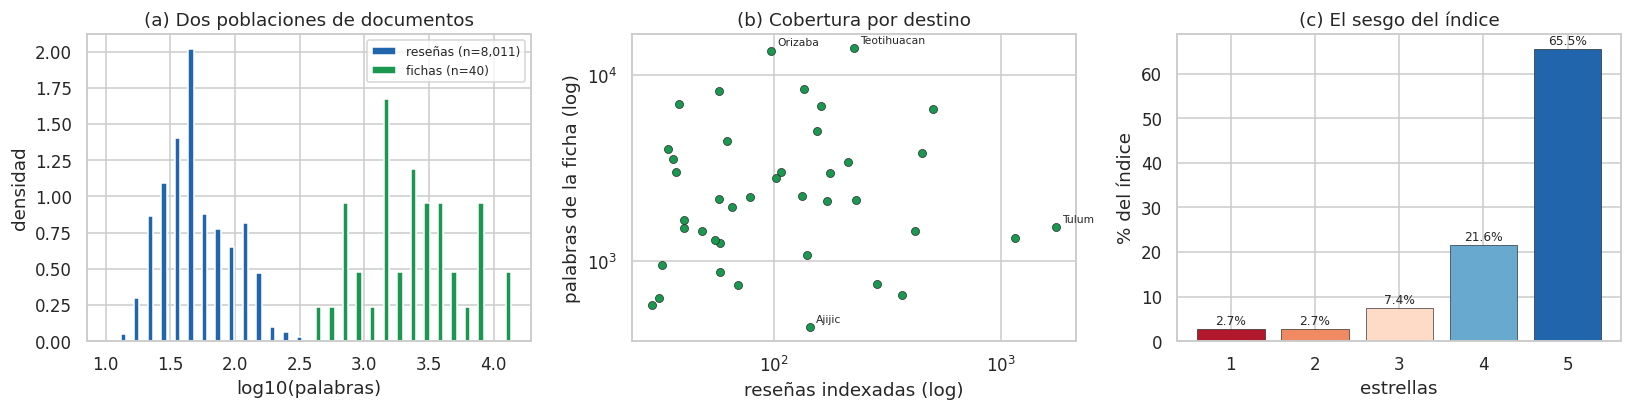

Razón de longitudes (mediana ficha / mediana reseña): 45x
Destinos con menos de 50 reseñas indexadas: 10
Reseñas negativas (1★-2★) en el índice: 5.4%


In [26]:
# =========================================================================
# 2.3 · EDA de las dos fuentes
# =========================================================================
largo_f = fichas_df["palabras"]
largo_r = resenas_df["texto"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))

# (a) longitudes, en escala logarítmica porque difieren en dos órdenes de magnitud
axes[0].hist([np.log10(largo_r), np.log10(largo_f)], bins=30, density=True,
             label=[f"reseñas (n={len(largo_r):,})", f"fichas (n={len(largo_f)})"],
             color=[PALETA_FUENTE["resena"], PALETA_FUENTE["ficha"]])
axes[0].set_xlabel("log10(palabras)"); axes[0].set_ylabel("densidad")
axes[0].set_title("(a) Dos poblaciones de documentos"); axes[0].legend(fontsize=8)

# (b) cobertura por destino: cuántas reseñas y qué ficha le toca a cada uno
cob = (resenas_df.groupby("Town").size().rename("resenas").to_frame()
       .join(fichas_df.set_index("destino")["palabras"].rename("palabras_ficha"))
       .sort_values("resenas", ascending=False))
axes[1].scatter(cob["resenas"], cob["palabras_ficha"], s=28,
                color=PALETA_FUENTE["ficha"], edgecolor="k", linewidth=0.4)
for d in ["Tulum", "Ajijic", "Teotihuacan", "Orizaba"]:
    if d in cob.index:
        axes[1].annotate(d, (cob.loc[d, "resenas"], cob.loc[d, "palabras_ficha"]),
                         fontsize=7, xytext=(4, 3), textcoords="offset points")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("reseñas indexadas (log)"); axes[1].set_ylabel("palabras de la ficha (log)")
axes[1].set_title("(b) Cobertura por destino")

# (c) estrellas: el sesgo del índice, que es lo que H1 pone a prueba
dist = resenas_df["Polarity"].value_counts(normalize=True).sort_index() * 100
axes[2].bar(dist.index, dist.values, color=[PALETA_POL[e] for e in dist.index],
            edgecolor="k", linewidth=0.4)
for e, v in dist.items():
    axes[2].text(e, v + 1, f"{v:.1f}%", ha="center", fontsize=8)
axes[2].set_xlabel("estrellas"); axes[2].set_ylabel("% del índice")
axes[2].set_title("(c) El sesgo del índice")

plt.tight_layout()
plt.savefig(DIR_RES / "figures" / "eda_corpus.png", bbox_inches="tight"); plt.show()

print(f"Razón de longitudes (mediana ficha / mediana reseña): "
      f"{largo_f.median() / largo_r.median():.0f}x")
print(f"Destinos con menos de 50 reseñas indexadas: {(cob['resenas'] < 50).sum()}")
print(f"Reseñas negativas (1★-2★) en el índice: {(resenas_df['Polarity'] <= 2).mean()*100:.1f}%")

Las dos fuentes casi no se parecen. Las fichas son textos largos y enciclopédicos, las reseñas son textos cortos escritos por personas, y la diferencia de longitud es de más de un orden de magnitud. La cobertura por destino también es desigual: hay destinos con muchas reseñas y una ficha corta, y otros con una ficha larga y pocas reseñas. Además, el índice está inclinado hacia lo positivo, con muy pocas reseñas negativas. Estas tres asimetrías son las condiciones en las que va a trabajar el recuperador, y conviene tenerlas presentes al leer sus métricas.

---

## 3. Partición en trozos: una estrategia por fuente

El guía parte **todos** los documentos en trozos del mismo tamaño con solapamiento, que es lo
sensato para artículos largos. Aquí eso sería un error en la mitad del corpus, y es la primera
hipótesis que ponemos a prueba.

**Las fichas sí se parten.** Una ficha de 13.965 palabras (Teotihuacán) no cabe en el contexto del
modelo y, sobre todo, no debe competir como un solo vector: su párrafo sobre el clima y el que
habla de la pirámide del Sol tratan temas distintos y tienen que ser recuperables por separado.

**¿De qué tamaño?** Hay un compromiso real: trozos grandes conservan el contexto que hace
interpretable un hecho, y trozos pequeños representan un solo tema y por eso puntúan más limpio.
Nuestra intuición inicial fue que ganarían los grandes, y **la medición de §8.1 dice lo
contrario**, así que el valor por omisión (110 palabras con 20 de solape) viene de ahí y no de la
intuición. Conviene leer esta celda sabiendo que el número está justificado más adelante.

**Las reseñas no se parten.** Una reseña tiene mediana de 48 palabras y es una **unidad de sentido
cerrada**: un autor, una valoración, una estrella. Partirla produce fragmentos sin polaridad
reconocible y, lo que es peor para esta entrega, **rompe la correspondencia entre documento y
etiqueta**, que es la base de toda la evaluación de §6 y §7 (D-505).

In [27]:
# =========================================================================
# 3 · Partición en trozos y corpus unificado
# =========================================================================
def partir(texto, palabras_por_trozo, solape):
    """Parte por palabras respetando el solape. Devuelve lista de trozos."""
    pal = texto.split()
    if len(pal) <= palabras_por_trozo:
        return [texto]
    paso = max(1, palabras_por_trozo - solape)
    return [" ".join(pal[i:i + palabras_por_trozo]) for i in range(0, len(pal), paso)
            if len(pal[i:i + palabras_por_trozo]) >= 40]        # se descarta la cola mínima

docs = []

# Las fichas, partidas
for f in fichas_df.itertuples():
    for j, trozo in enumerate(partir(f.texto, CFG["chunk_ficha"], CFG["solape_ficha"])):
        docs.append({"texto": trozo, "fuente": "ficha", "destino": f.destino,
                     "titulo": f.titulo_wikipedia, "url": f.url,
                     "tipo": None, "estrellas": None, "trozo": j})

# Las reseñas, enteras
for r in resenas_df.itertuples():
    docs.append({"texto": r.texto, "fuente": "resena", "destino": r.Town,
                 "titulo": None, "url": None,
                 "tipo": r.Type, "estrellas": int(r.Polarity), "trozo": 0})

corpus = pd.DataFrame(docs)
corpus["palabras"] = corpus["texto"].str.split().str.len()

n_fi = (corpus.fuente == "ficha").sum()
print(f"Corpus unificado: {len(corpus):,} documentos")
print(f"  trozos de ficha : {n_fi:,} (de {len(fichas_df)} fichas, "
      f"{n_fi/len(fichas_df):.1f} trozos por ficha)")
print(f"  reseñas enteras : {(corpus.fuente=='resena').sum():,}")
print(f"\nPalabras por documento:")
display(corpus.groupby("fuente")["palabras"].describe()[["count", "mean", "50%", "min", "max"]].round(1))

Corpus unificado: 9,478 documentos
  trozos de ficha : 1,467 (de 40 fichas, 36.7 trozos por ficha)
  reseñas enteras : 8,011

Palabras por documento:


,count,mean,50%,min,max
fuente,,,,,
ficha,1467.0,109.3,110.0,41.0,110.0
resena,8011.0,65.0,48.0,10.0,907.0


Las fichas quedan en trozos de tamaño casi uniforme, limitado por el valor configurado, mientras que las reseñas conservan su longitud natural y varían bastante entre sí. Es lo buscado: un trozo de ficha es un fragmento de un texto largo que no cabría entero en el contexto, y una reseña ya es una unidad completa. Un destino con una ficha larga aporta muchos trozos al índice, así que sus candidatos enciclopédicos son numerosos frente a los de un destino con una ficha corta.

---

## 4. *Embeddings* y vector store

El recuperador denso proyecta cada documento a un vector y busca por similitud. Dos decisiones
importan aquí.

**El codificador.** Usamos la familia **E5 multilingüe**, que es la del guía, en su versión
`small` como principal porque corre en CPU en un tiempo razonable, y comparamos con `large` en
esta misma sección para poner número al compromiso entre calidad y costo. E5 exige **prefijos
asimétricos**: los documentos se codifican con `passage: ` y las consultas con `query: `. No es un
detalle estético: el modelo se entrenó así y omitirlo degrada la recuperación.

**La similitud.** Normalizamos los vectores, de modo que el producto punto es el **coseno**. Con
documentos de longitudes tan dispares como las nuestras (trozos de 220 palabras frente a reseñas
de 48) esto evita que la norma del vector, que correlaciona con la longitud, se cuele en el
ranking.

In [28]:
# =========================================================================
# 4 · Embeddings y vector store
# =========================================================================
from sentence_transformers import SentenceTransformer

def construir_store(nombre_modelo, textos, etiqueta, lote=None):
    """Codifica el corpus y guarda el resultado en caché. Devuelve (modelo, matriz, segundos)."""
    ruta = DIR_DATOS / f"vectorstore_{etiqueta}_{len(textos)}.npy"
    modelo = SentenceTransformer(nombre_modelo, device=DISPOSITIVO)
    if ruta.exists():
        store = np.load(ruta)
        print(f"{etiqueta}: store leído de caché {store.shape}")
        return modelo, store, 0.0
    t0 = time.time()
    store = modelo.encode([f"passage: {t}" for t in textos],       # prefijo de documento de E5
                          batch_size=lote or CFG["lote_embed"],
                          normalize_embeddings=True,                # coseno via producto punto
                          show_progress_bar=False, convert_to_numpy=True)
    seg = time.time() - t0
    np.save(ruta, store.astype(np.float32))
    print(f"{etiqueta}: {store.shape} en {seg:.0f}s ({len(textos)/seg:.0f} docs/s)")
    return modelo, store.astype(np.float32), seg

codificador, STORE, seg_principal = construir_store(
    CODIFICADOR, corpus["texto"].tolist(), "e5small")
DIM = STORE.shape[1]
print(f"\nDimensión: {DIM} | memoria del store: {STORE.nbytes/2**20:.1f} MiB")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

e5small: (9478, 384) en 23s (404 docs/s)

Dimensión: 384 | memoria del store: 13.9 MiB


Dos precisiones sobre esta sección. La explicación de arriba habla de trozos de 220 palabras, pero el tamaño vigente es el de la configuración, con solape; la idea de fondo no cambia, porque la diferencia de longitud con las reseñas sigue siendo grande. Y el costo de construir el índice se paga una sola vez: codificar todo el corpus es la parte pesada y queda guardado en disco, mientras que cada consulta solo necesita codificar una frase corta. Por eso, si se añaden documentos nuevos, basta con codificar los nuevos y no hay que rehacer lo anterior.

---

## 5. El recuperador

El guía implementa el recuperador como una clase con producto punto y `argsort`, y eso es
exactamente lo correcto a esta escala: con unos pocos miles de documentos, una multiplicación de
matrices en NumPy es más rápida que montar un índice aproximado, y además es exacta.

Nuestra versión añade lo que el caso necesita: **filtros por metadatos**. Poder restringir la
búsqueda a un destino, a una fuente o a un rango de estrellas es lo que §7 usará para cerrar el
agujero de la polaridad, así que el recuperador lo soporta desde el principio.

In [29]:
# =========================================================================
# 5 · Recuperador denso con filtros de metadatos
# =========================================================================
class Recuperador:
    """Búsqueda densa exacta sobre el store, con filtros opcionales por metadatos."""

    def __init__(self, corpus: pd.DataFrame, store: np.ndarray, modelo: SentenceTransformer):
        self.corpus, self.store, self.modelo = corpus.reset_index(drop=True), store, modelo

    def _mascara(self, destino=None, fuente=None, tipo=None, estrellas=None):
        m = np.ones(len(self.corpus), dtype=bool)
        if destino is not None:
            m &= self.corpus["destino"].isin(np.atleast_1d(destino)).values
        if fuente is not None:
            m &= self.corpus["fuente"].isin(np.atleast_1d(fuente)).values
        if tipo is not None:
            m &= self.corpus["tipo"].isin(np.atleast_1d(tipo)).values
        if estrellas is not None:                      # (minimo, maximo), inclusive
            lo, hi = estrellas
            e = self.corpus["estrellas"]
            m &= e.between(lo, hi).fillna(False).values
        return m

    def buscar(self, consulta: str, k: int = None, **filtros) -> pd.DataFrame:
        k = k or CFG["k"]
        q = self.modelo.encode([f"query: {consulta}"],             # prefijo de consulta de E5
                               normalize_embeddings=True, convert_to_numpy=True)[0]
        puntajes = self.store @ q                                   # coseno, por estar normalizado
        m = self._mascara(**filtros)
        if not m.any():
            return self.corpus.head(0).assign(puntaje=[])
        puntajes = np.where(m, puntajes, -np.inf)
        top = np.argpartition(-puntajes, min(k, m.sum() - 1))[:k]
        top = top[np.argsort(-puntajes[top])]
        return self.corpus.iloc[top].assign(puntaje=puntajes[top])

recuperador = Recuperador(corpus, STORE, codificador)

def mostrar(res: pd.DataFrame, ancho=110):
    """Imprime resultados de forma legible, con la cita que corresponde a cada fuente."""
    for _, r in res.iterrows():
        if r["fuente"] == "ficha":
            cita = f"ficha · {r['destino']} · {r['titulo']}"
        else:
            cita = f"reseña · {r['destino']} · {r['tipo']} · {int(r['estrellas'])}★"
        print(f"[{r['puntaje']:.3f}] {cita}")
        print(textwrap.fill(r["texto"][:300], ancho, initial_indent="    ",
                            subsequent_indent="    "))
        print()

fijar_semilla()
print("### Pregunta de HECHO: ¿Qué es la laguna de Bacalar?\n")
mostrar(recuperador.buscar("¿Qué es la laguna de Bacalar?", k=3))
print("### Pregunta de EXPERIENCIA: ¿Cómo es el servicio en los hoteles de Bacalar?\n")
mostrar(recuperador.buscar("¿Cómo es el servicio en los hoteles de Bacalar?", k=3))

### Pregunta de HECHO: ¿Qué es la laguna de Bacalar?

[0.898] reseña · Bacalar · Attractive · 5★
    Espectacular. Visita obligada . La laguna de Bacalar es una joya del sur de Quintana Roo. Sin duda es un
    lugar que debes visitar y disfrutar. Muy recomendable hacer un paseo en la laguna y visitar el canal de
    los piratas y los cenotes.

[0.891] reseña · Bacalar · Attractive · 4★
    Impresionante . Lugar impresionante donde se puede apreciar la grandeza de la laguna de Bacalar y su
    colorido del agua.

[0.890] reseña · Bacalar · Attractive · 5★
    Lugar mágico. Un lugar soñado por cualquier persona que desee paz y tranquilidad. Aguas cristalinas,
    templada y calma hace que la laguna de Bacalar sea un sitio en el cual no podes dejar de volver.

### Pregunta de EXPERIENCIA: ¿Cómo es el servicio en los hoteles de Bacalar?

[0.887] reseña · Bacalar · Hotel · 4★
    Encantador... .... Así como se ve en las fotos así es. El lugar es ideal para desconectarse de todo y
    disfru

Dos observaciones sobre estos ejemplos. La primera es que los puntajes de los primeros resultados son casi iguales y se mueven en una franja estrecha y alta, así que el valor absoluto de la similitud dice poco y lo que informa es el orden. La segunda es que la pregunta de hecho trajo reseñas y no la ficha: el recuperador acertó el tema y el destino, pero no el tipo de documento, porque una reseña que repite el nombre del lugar se parece mucho a la pregunta. La pregunta de experiencia, en cambio, trae justo lo que se espera. Esta diferencia entre acertar el tema y acertar el tipo de fuente es lo que mide la sección siguiente.

---

## 6. El banco de preguntas: cómo se mide un RAG sin leer sus respuestas

Esta es la sección que separa esta entrega del notebook guía, así que vale la pena explicar la
idea antes del código.

Evaluar un RAG es incómodo porque la respuesta correcta es un texto, y comparar textos exige una
persona que lea o un modelo que juzgue. El guía resuelve esto mirando la salida y comentándola; el
Miniproyecto 4 nos enseñó, además, que **usar un modelo como juez cuando ese modelo forma parte
del sistema introduce una circularidad** que infla el resultado.

Aquí hay una salida mejor, y es específica de este corpus: **la respuesta correcta se puede
expresar en metadatos**. No escribimos «la respuesta debe decir que Bacalar es una laguna de siete
colores», que haría falta comparar palabra por palabra. Escribimos que una pregunta por hechos de
Bacalar **debe recuperar documentos con `fuente=ficha` y `destino=Bacalar`**, y eso se comprueba
con una comparación de columnas.

Cada pregunta declara entonces su **objetivo**: qué fuente, qué destino y, cuando aplica, qué tipo
de establecimiento y qué rango de estrellas. Un documento recuperado es **relevante** si cumple
todas las restricciones declaradas. Con eso se calculan métricas estándar de recuperación:

- **Precisión@k**: de los `k` recuperados, cuántos son relevantes.
- **MRR** (*mean reciprocal rank*): qué tan arriba aparece el primer relevante. Castiga poner lo
  bueno en el puesto cinco.
- **Acierto de fuente** y **de destino** por separado, para ver *en qué* se equivoca.

Las cuatro familias de preguntas están pensadas para aislar un fallo distinto cada una.

In [30]:
# =========================================================================
# 6 · Banco de preguntas con la respuesta correcta en metadatos
# =========================================================================
# Cada entrada declara el objetivo de la recuperación, nunca un texto esperado.
#   familia:  A hechos · B experiencia · C experiencia por tipo · D lo negativo
BANCO = [
    # --- A. Hechos de destino: debe ganar la ficha ---
    dict(familia="A", pregunta="¿Qué es la laguna de Bacalar y por qué la llaman de siete colores?",
         fuente="ficha", destino="Bacalar"),
    dict(familia="A", pregunta="¿Qué cultura construyó las pirámides de Teotihuacán?",
         fuente="ficha", destino="Teotihuacan"),
    dict(familia="A", pregunta="¿Dónde se encuentra la ciudad de Valladolid en Yucatán?",
         fuente="ficha", destino="Valladolid"),
    dict(familia="A", pregunta="¿Qué es Las Pozas de Xilitla y quién lo construyó?",
         fuente="ficha", destino="Xilitla"),
    dict(familia="A", pregunta="¿Cuál es el origen del nombre de Isla Mujeres?",
         fuente="ficha", destino="Isla_Mujeres"),
    dict(familia="A", pregunta="¿Qué importancia tiene la bebida en el municipio de Tequila?",
         fuente="ficha", destino="Tequila"),
    dict(familia="A", pregunta="¿Qué se sabe de la historia de la ciudad maya de Tulum?",
         fuente="ficha", destino="Tulum"),
    dict(familia="A", pregunta="¿Por qué es conocida la platería en Taxco?",
         fuente="ficha", destino="Taxco"),

    # --- B. Experiencia general: debe ganar la reseña ---
    dict(familia="B", pregunta="¿Qué cuentan los viajeros sobre su visita a Tulum?",
         fuente="resena", destino="Tulum"),
    dict(familia="B", pregunta="¿Cómo describen la experiencia de recorrer San Cristóbal de las Casas?",
         fuente="resena", destino="San_Cristobal_de_las_Casas"),
    dict(familia="B", pregunta="¿Vale la pena el paseo en lancha en Bacalar según quienes lo hicieron?",
         fuente="resena", destino="Bacalar"),
    dict(familia="B", pregunta="¿Qué opinan los visitantes de Sayulita?",
         fuente="resena", destino="Sayulita"),

    # --- C. Experiencia por tipo de establecimiento ---
    dict(familia="C", pregunta="¿Cómo es la comida en los restaurantes de Tulum?",
         fuente="resena", destino="Tulum", tipo="Restaurant"),
    dict(familia="C", pregunta="¿Qué tal son los hoteles de Isla Mujeres?",
         fuente="resena", destino="Isla_Mujeres", tipo="Hotel"),
    dict(familia="C", pregunta="¿Cómo es la atención en los hoteles de Valladolid?",
         fuente="resena", destino="Valladolid", tipo="Hotel"),
    dict(familia="C", pregunta="¿Qué dicen de los restaurantes de Sayulita?",
         fuente="resena", destino="Sayulita", tipo="Restaurant"),
    dict(familia="C", pregunta="¿Cómo es la visita a la zona arqueológica de Palenque?",
         fuente="resena", destino="Palenque", tipo="Attractive"),

    # --- D. Lo negativo: la prueba de H1 ---
    dict(familia="D", pregunta="¿Qué problemas reportan los huéspedes de los hoteles de Tulum?",
         fuente="resena", destino="Tulum", tipo="Hotel", estrellas=(1, 2)),
    dict(familia="D", pregunta="¿Cuáles son las peores quejas sobre los restaurantes de Tulum?",
         fuente="resena", destino="Tulum", tipo="Restaurant", estrellas=(1, 2)),
    dict(familia="D", pregunta="¿Por qué algunos visitantes quedaron decepcionados de Isla Mujeres?",
         fuente="resena", destino="Isla_Mujeres", estrellas=(1, 2)),
    dict(familia="D", pregunta="¿Qué critican los viajeros de los hoteles de San Cristóbal de las Casas?",
         fuente="resena", destino="San_Cristobal_de_las_Casas", tipo="Hotel", estrellas=(1, 2)),
    dict(familia="D", pregunta="¿Qué salió mal en las visitas a Teotihuacán?",
         fuente="resena", destino="Teotihuacan", estrellas=(1, 2)),
    dict(familia="D", pregunta="¿De qué se queja la gente en Bacalar?",
         fuente="resena", destino="Bacalar", estrellas=(1, 2)),
]

banco_df = pd.DataFrame(BANCO)
print(f"{len(banco_df)} preguntas en el banco")
display(banco_df.groupby("familia").agg(preguntas=("pregunta", "size"),
                                        con_tipo=("tipo", lambda s: s.notna().sum()),
                                        con_estrellas=("estrellas", lambda s: s.notna().sum())))

# Cuántos documentos del índice podrían satisfacer cada pregunta: si son muy pocos, la
# precisión@k está acotada por arriba y hay que saberlo antes de interpretar los números.
def n_relevantes(p):
    m = (corpus["fuente"] == p["fuente"]) & (corpus["destino"] == p["destino"])
    if p.get("tipo") is not None and not pd.isna(p.get("tipo")):
        m &= corpus["tipo"] == p["tipo"]
    if p.get("estrellas") is not None and not (isinstance(p.get("estrellas"), float)):
        lo, hi = p["estrellas"]
        m &= corpus["estrellas"].between(lo, hi).fillna(False)
    return int(m.sum())

banco_df["relevantes_en_indice"] = [n_relevantes(p) for p in BANCO]
print("\nDocumentos relevantes disponibles por familia:")
display(banco_df.groupby("familia")["relevantes_en_indice"].describe()[["min", "50%", "max"]].round(0))

23 preguntas en el banco


,preguntas,con_tipo,con_estrellas
familia,,,
A,8,0,0
B,4,0,0
C,5,5,0
D,6,3,6



Documentos relevantes disponibles por familia:


,min,50%,max
familia,,,
A,14.0,24.0,155.0
B,283.0,458.0,1743.0
C,98.0,179.0,357.0
D,8.0,17.0,51.0


Ninguna familia tiene menos documentos relevantes que el número de resultados que se recuperan, así que la precisión no está limitada por construcción y sus valores se pueden leer tal cual. Las familias de hechos y de lo negativo son las que tienen menos margen, porque hay pocos documentos que cumplan lo pedido, y eso las hace las más exigentes del banco.

La última tabla es un control de cordura que conviene mirar antes de cualquier resultado: si
una pregunta de la familia D tuviera, por ejemplo, 3 documentos relevantes en todo el índice, su
precisión@5 **no podría pasar de 0,6** por construcción, y leer un 0,4 como un fallo del
recuperador sería injusto. El mínimo por familia dice cuánto margen hay de verdad.

In [31]:
# =========================================================================
# 6 · Métricas de recuperación
# =========================================================================
def es_relevante(res: pd.DataFrame, p: dict) -> np.ndarray:
    """Un documento es relevante si cumple TODAS las restricciones declaradas."""
    ok = (res["fuente"] == p["fuente"]).values & (res["destino"] == p["destino"]).values
    if p.get("tipo") is not None and not (isinstance(p.get("tipo"), float)):
        ok &= (res["tipo"] == p["tipo"]).values
    if p.get("estrellas") is not None and not (isinstance(p.get("estrellas"), float)):
        lo, hi = p["estrellas"]
        ok &= res["estrellas"].between(lo, hi).fillna(False).values
    return ok

def evaluar_recuperador(buscar, banco=BANCO, k=None, etiqueta="denso"):
    """Corre el banco completo y devuelve (resumen por familia, detalle por pregunta)."""
    k = k or CFG["k"]
    filas = []
    for p in banco:
        t0 = time.time()
        res = buscar(p["pregunta"], k=k)
        ms = (time.time() - t0) * 1000
        rel = es_relevante(res, p)
        pos = np.where(rel)[0]
        filas.append({
            # La columna se llama "precision" y no "precision@k": en §8 se comparan variantes
            # con k distinto, y un nombre que dependa de k las volvería incomparables.
            "familia": p["familia"], "pregunta": p["pregunta"], "k": k,
            "precision": rel.mean(),
            "acierto_fuente": (res["fuente"] == p["fuente"]).mean(),
            "acierto_destino": (res["destino"] == p["destino"]).mean(),
            "mrr": 1.0 / (pos[0] + 1) if len(pos) else 0.0,
            "algun_relevante": float(rel.any()),
            "ms": ms,
        })
    det = pd.DataFrame(filas)
    cols = [c for c in det.columns if c not in ("familia", "pregunta")]
    resumen = det.groupby("familia")[cols].mean()
    resumen.loc["TODAS"] = det[cols].mean()
    return resumen.round(3), det

fijar_semilla()
RES_DENSO, DET_DENSO = evaluar_recuperador(recuperador.buscar, etiqueta="denso")
print(f"Recuperador denso, k={CFG['k']}, {len(BANCO)} preguntas\n")
display(RES_DENSO)

Recuperador denso, k=5, 23 preguntas



,k,precision,acierto_fuente,acierto_destino,mrr,algun_relevante,ms
familia,,,,,,,
A,5.0,0.650,0.650,1.000,0.812,0.875,18.764
B,5.0,0.900,0.900,1.000,1.000,1.000,24.203
C,5.0,1.000,1.000,1.000,1.000,1.000,16.132
D,5.0,0.167,0.833,0.967,0.222,0.333,16.124
TODAS,5.0,0.643,0.817,0.991,0.732,0.783,18.449


El patrón es claro y distinto en cada familia. El destino se acierta casi siempre, así que el recuperador denso rara vez se equivoca de lugar. Las preguntas de experiencia general van bien, y las que además nombran el tipo de establecimiento van todavía mejor, porque esa palabra ya separa los documentos por tema. Las preguntas de hechos fallan en el tipo de fuente: las reseñas se cuelan antes que la ficha, aunque sí aparece algún documento correcto. Y las preguntas sobre lo negativo son el punto débil: el sistema encuentra el lugar y el tipo de establecimiento, pero no distingue la opinión, porque una queja y un elogio hablan del mismo tema.

In [34]:
for fam in ("A", "D"):
    print(f"Familia {fam}")
    display(DET_DENSO[DET_DENSO["familia"] == fam][["pregunta", "precision", "acierto_fuente", "mrr"]].round(2))

Familia A


,pregunta,precision,acierto_fuente,mrr
0,¿Qué es la laguna de Bacalar y por qué la llam...,0.0,0.0,0.0
1,¿Qué cultura construyó las pirámides de Teotih...,1.0,1.0,1.0
2,¿Dónde se encuentra la ciudad de Valladolid en...,1.0,1.0,1.0
3,¿Qué es Las Pozas de Xilitla y quién lo constr...,0.8,0.8,1.0
4,¿Cuál es el origen del nombre de Isla Mujeres?,0.8,0.8,1.0
5,¿Qué importancia tiene la bebida en el municip...,0.6,0.6,1.0
6,¿Qué se sabe de la historia de la ciudad maya ...,0.4,0.4,1.0
7,¿Por qué es conocida la platería en Taxco?,0.6,0.6,0.5


Familia D


,pregunta,precision,acierto_fuente,mrr
17,¿Qué problemas reportan los huéspedes de los h...,0.0,1.0,0.00
18,¿Cuáles son las peores quejas sobre los restau...,0.0,1.0,0.00
19,¿Por qué algunos visitantes quedaron decepcion...,0.8,1.0,1.00
20,¿Qué critican los viajeros de los hoteles de S...,0.2,0.8,0.33
21,¿Qué salió mal en las visitas a Teotihuacán?,0.0,0.8,0.00
22,¿De qué se queja la gente en Bacalar?,0.0,0.4,0.00


El detalle muestra que el fallo depende de la pregunta y no de la familia en bloque. Entre las preguntas de hechos, las que tratan un tema muy propio del lugar, como una cultura o una historia, traen la ficha sin problema, mientras que la que gira en torno a algo que los viajeros repiten una y otra vez, como la propia laguna, pierde frente a las reseñas, que se parecen más a la pregunta que el texto enciclopédico. Entre las preguntas sobre lo negativo ocurre algo parecido: funcionan mejor las que usan una palabra de opinión que las reseñas también usan, y peor las que piden en general problemas o quejas, que son palabras del tema de la pregunta y no del tono de las reseñas.

---

## 7. H1: el agujero de la polaridad

La tabla anterior ya debería mostrar el patrón que anticipamos, pero conviene medirlo de frente,
porque es el hallazgo central de la entrega.

La idea de H1 es que un *embedding* denso codifica **de qué habla** un texto y solo muy
débilmente **qué opina**. «El desayuno estaba delicioso» y «el desayuno estaba frío e incomible»
comparten tema, vocabulario de dominio y estructura; difieren en un adjetivo. En el espacio
vectorial quedan vecinos, así que una consulta por quejas sobre el desayuno recupera las dos.

La consecuencia práctica es grave para un asistente de viajes: si un usuario pregunta qué puede
salir mal en un hotel y el sistema le devuelve mayoritariamente elogios, **la respuesta será
tranquilizadora y falsa**. Y como el índice tiene un 66 % de reseñas de 5★, el sesgo del corpus
empuja en la misma dirección.

La medimos comparando tres distribuciones de estrellas: la del índice, la de lo que recupera el
recuperador denso ante las preguntas de la familia D, y la de lo que recuperaría si filtrásemos
por metadatos.

In [35]:
# =========================================================================
# 7 · ¿Recupera por polaridad o solo por tema?
# =========================================================================
preguntas_D = [p for p in BANCO if p["familia"] == "D"]

def distribucion_estrellas(buscar, preguntas, k=10, **filtros):
    """Estrellas de todo lo recuperado (solo reseñas) para un conjunto de preguntas."""
    est = []
    for p in preguntas:
        res = buscar(p["pregunta"], k=k, **filtros)
        est += res.loc[res["fuente"] == "resena", "estrellas"].dropna().astype(int).tolist()
    return pd.Series(est)

fijar_semilla()
est_denso = distribucion_estrellas(recuperador.buscar, preguntas_D, k=10)
est_indice = resenas_df["Polarity"]

# El mismo recuperador, pero restringido a reseñas negativas por metadatos
est_filtro = distribucion_estrellas(recuperador.buscar, preguntas_D, k=10,
                                    fuente="resena", estrellas=(1, 2))

tabla_h1 = pd.DataFrame({
    "índice completo": est_indice.value_counts(normalize=True).sort_index() * 100,
    "denso, sin filtro": est_denso.value_counts(normalize=True).sort_index() * 100,
    "con filtro de metadatos": est_filtro.value_counts(normalize=True).sort_index() * 100,
}).fillna(0).round(1)
tabla_h1.index.name = "estrellas"
display(tabla_h1)

neg = lambda s: (s <= 2).mean() * 100
print(f"Reseñas negativas (1★-2★) al preguntar POR LO NEGATIVO:")
print(f"  en el índice, por azar        : {neg(est_indice):5.1f}%")
print(f"  recuperador denso sin filtro  : {neg(est_denso):5.1f}%")
print(f"  con filtro de metadatos       : {neg(est_filtro):5.1f}%")
print(f"\nEstrella media de lo recuperado: denso {est_denso.mean():.2f} | "
      f"filtro {est_filtro.mean():.2f} | índice {est_indice.mean():.2f}")

,índice completo,"denso, sin filtro",con filtro de metadatos
estrellas,,,
1,2.7,17.6,65.0
2,2.7,7.8,35.0
3,7.4,27.5,0.0
4,21.6,11.8,0.0
5,65.5,35.3,0.0


Reseñas negativas (1★-2★) al preguntar POR LO NEGATIVO:
  en el índice, por azar        :   5.4%
  recuperador denso sin filtro  :  25.5%
  con filtro de metadatos       : 100.0%

Estrella media de lo recuperado: denso 3.39 | filtro 1.35 | índice 4.45


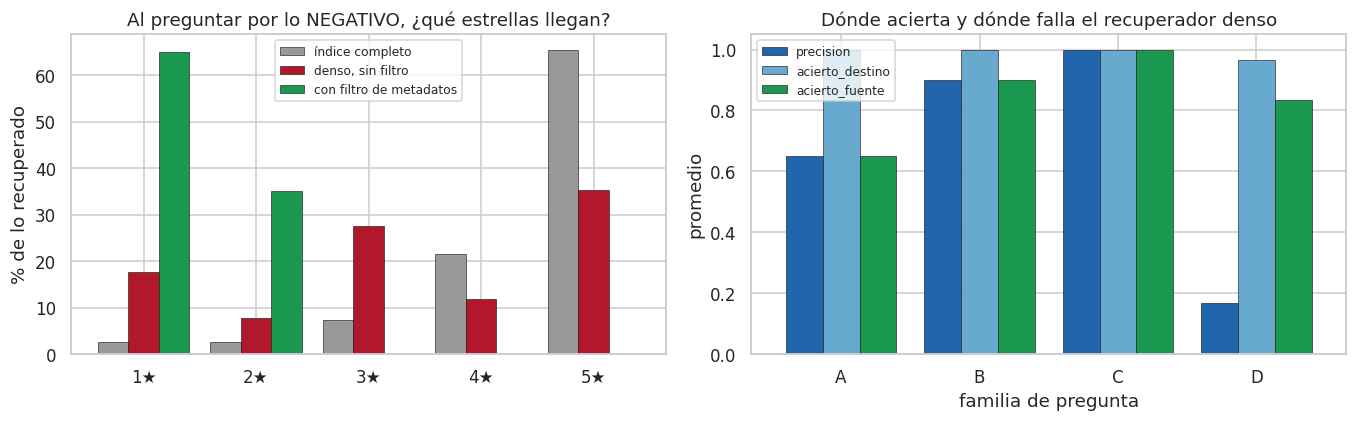

In [36]:
# =========================================================================
# 7 · La gráfica de H1
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

x = np.arange(1, 6)
ancho = 0.27
for i, (col, color) in enumerate(zip(tabla_h1.columns, ["#999999", "#b2182b", "#1a9850"])):
    vals = tabla_h1[col].reindex(x, fill_value=0).values
    axes[0].bar(x + (i - 1) * ancho, vals, ancho, label=col, color=color,
                edgecolor="k", linewidth=0.4)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{e}★" for e in x])
axes[0].set_ylabel("% de lo recuperado"); axes[0].legend(fontsize=8)
axes[0].set_title("Al preguntar por lo NEGATIVO, ¿qué estrellas llegan?")

# Precisión por familia: se ve dónde falla el denso
prec = RES_DENSO.drop(index="TODAS")[["precision", "acierto_destino", "acierto_fuente"]]
prec.plot(kind="bar", ax=axes[1], color=["#2166ac", "#67a9cf", "#1a9850"],
          edgecolor="k", linewidth=0.4, width=0.8)
axes[1].set_xlabel("familia de pregunta"); axes[1].set_ylabel("promedio")
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8); axes[1].tick_params(axis="x", rotation=0)
axes[1].set_title("Dónde acierta y dónde falla el recuperador denso")

plt.tight_layout()
plt.savefig(DIR_RES / "figures" / "h1_polaridad.png", bbox_inches="tight"); plt.show()

La consulta por lo negativo mueve el resultado en la dirección correcta, pero se queda corta. Frente a lo que saldría al azar, el recuperador denso trae bastantes más reseñas negativas y la distribución se desplaza hacia las estrellas bajas, con un peso notable en las intermedias. Aun así, la mayor parte de lo que recupera no es negativo, y una porción importante sigue siendo elogio. El *embedding* sí lleva algo de señal de polaridad, pero débil: el tema domina sobre la opinión. Cuando se restringe por metadatos, todo lo recuperado es negativo, como no podía ser de otra forma, porque el filtro usa la etiqueta que el recuperador no ve. Ese resultado es una cota superior y no un sistema real, ya que el filtro solo se puede aplicar si alguien sabe de antemano que la pregunta busca lo negativo. El gráfico de la derecha resume las cuatro familias: el destino casi siempre se acierta, falla el tipo de fuente en los hechos y falla la polaridad en lo negativo.

---

## 8. Estudios de recuperación

Cuatro preguntas sobre el recuperador, cada una con su experimento y todas medidas con el mismo
banco de §6. Van juntas a propósito: son variaciones de una misma pieza, y separarlas en cuatro
secciones alargaría el notebook sin añadir nada.

1. **¿Cuál es el tamaño de trozo correcto, y es el mismo para las dos fuentes?** (H2)
2. **¿Cuánto se gana con un codificador más grande, y cuánto cuesta?**
3. **¿Ayuda reordenar con un modelo que mira la pareja consulta-documento?**
4. **¿Y mezclar la búsqueda densa con una léxica, BM25?**

### 8.1 El tamaño del trozo (H2)

Las reseñas no se parten, eso está decidido y argumentado (D-505). La pregunta abierta es el
tamaño de trozo de las **fichas**, y tiene un compromiso claro: trozos pequeños son más precisos
(el vector representa una sola idea) pero parten los hechos a la mitad y pierden el contexto que
los hace interpretables; trozos grandes conservan el contexto pero diluyen el tema en un promedio.

Lo medimos reindexando **solo las fichas** con tres tamaños y evaluando con las preguntas de la
familia A, que son las que deben responderse con fichas.

In [37]:
# =========================================================================
# 8.1 · Tamaño de trozo de las fichas (H2)
# =========================================================================
preguntas_A = [p for p in BANCO if p["familia"] == "A"]
TAMANOS = [(110, 20), (220, 40), (450, 80)]       # (palabras, solape)

filas_h2 = []
for tam, sol in TAMANOS:
    trozos = []
    for f in fichas_df.itertuples():
        for j, tr in enumerate(partir(f.texto, tam, sol)):
            trozos.append({"texto": tr, "fuente": "ficha", "destino": f.destino,
                           "titulo": f.titulo_wikipedia, "url": f.url,
                           "tipo": None, "estrellas": None, "trozo": j})
    sub = pd.DataFrame(trozos)
    t0 = time.time()
    vec = codificador.encode([f"passage: {t}" for t in sub["texto"]],
                             batch_size=CFG["lote_embed"], normalize_embeddings=True,
                             show_progress_bar=False, convert_to_numpy=True)
    seg = time.time() - t0
    rec = Recuperador(sub, vec.astype(np.float32), codificador)
    res, _ = evaluar_recuperador(rec.buscar, preguntas_A)
    fila = res.loc["TODAS"].to_dict()
    filas_h2.append({"palabras por trozo": tam, "solape": sol, "trozos": len(sub),
                     "palabras medias": sub["texto"].str.split().str.len().mean(),
                     **{k: v for k, v in fila.items() if k != "ms"},
                     "segundos de indexado": seg})

tabla_h2 = pd.DataFrame(filas_h2).round(3)
tabla_h2.to_csv(DIR_RES / "metrics" / "h2_chunking.csv", index=False)
display(tabla_h2)

,palabras por trozo,solape,trozos,palabras medias,k,precision,acierto_fuente,acierto_destino,mrr,algun_relevante,segundos de indexado
0,110,20,1467,109.290,5.0,0.975,1.0,0.975,1.0,1.0,5.849
1,220,40,744,215.161,5.0,0.875,1.0,0.875,1.0,1.0,6.603
2,450,80,369,428.645,5.0,0.825,1.0,0.825,1.0,1.0,4.246


Entre los tamaños probados gana el más pequeño, y la calidad baja a medida que el trozo crece, mientras que el destino se acierta siempre. Es lo contrario de nuestra intuición inicial: un trozo grande diluye el tema en un promedio y compite peor que uno pequeño que trata una sola idea. Otra cosa que enseña esta tabla es que la precisión es mucho mayor que la de las preguntas de hechos en la evaluación general. La diferencia es que aquí el índice solo contiene fichas, así que no hay reseñas que compitan con ellas. El límite de las preguntas de hechos no está entonces en cómo se parten las fichas, sino en que las reseñas se cuelan antes. El tiempo de indexado no decide nada entre los tres tamaños.

In [38]:
# =========================================================================
# 8.1 · Complemento: un tamaño menor y el efecto del solape
# =========================================================================
def evaluar_tamano(tam, sol):
    trozos = []
    for f in fichas_df.itertuples():
        for j, tr in enumerate(partir(f.texto, tam, sol)):
            trozos.append({"texto": tr, "fuente": "ficha", "destino": f.destino,
                           "titulo": f.titulo_wikipedia, "url": f.url,
                           "tipo": None, "estrellas": None, "trozo": j})
    sub = pd.DataFrame(trozos)
    vec = codificador.encode([f"passage: {t}" for t in sub["texto"]],
                             batch_size=CFG["lote_embed"], normalize_embeddings=True,
                             show_progress_bar=False, convert_to_numpy=True)
    rec = Recuperador(sub, vec.astype(np.float32), codificador)
    res, _ = evaluar_recuperador(rec.buscar, preguntas_A)
    return {"palabras por trozo": tam, "solape": sol, "trozos": len(sub),
            **res.loc["TODAS"][["precision", "mrr"]].to_dict()}

tabla_extra = pd.DataFrame([evaluar_tamano(t, s)
                            for t, s in [(55, 10), (110, 0), (110, 20), (220, 0)]]).round(3)
display(tabla_extra)

,palabras por trozo,solape,trozos,precision,mrr
0,55,10,2915,0.950,0.938
1,110,0,1204,0.975,1.000
2,110,20,1467,0.975,1.000
3,220,0,612,0.875,1.000


El tamaño más pequeño no mejora: el mejor valor queda en el medio de lo probado y no en el extremo, y los trozos grandes siguen perdiendo. Con solape y sin solape el resultado es prácticamente el mismo en este banco, y el solape cuesta más trozos en el índice, así que su ventaja aquí es de seguridad, para no partir un hecho por la mitad, más que de métrica. Las diferencias entre tamaños cercanos equivalen a una o dos preguntas del banco, por lo que conviene leer solo la tendencia gruesa: lo muy grande pierde y, entre lo pequeño, la medición no separa.

### 8.2 El codificador: calidad frente a costo

`multilingual-e5-small` tiene 384 dimensiones y 118 millones de parámetros; `large` tiene 1.024
dimensiones y 560 millones. La pregunta no es cuál recupera mejor (va a ser el grande) sino
**cuánto mejor y a qué precio**, que es la comparación que el curso valora y la que decide en un
despliegue real. Esta celda solo corre con GPU: en CPU, `large` sobre miles de documentos tarda
demasiado para un notebook reproducible.

In [39]:
# =========================================================================
# 8.2 · Comparación de codificadores
# =========================================================================
filas_cod = [{"codificador": CODIFICADOR, "dimensión": DIM,
              "segundos de indexado": round(seg_principal, 1),
              **{k: v for k, v in RES_DENSO.loc["TODAS"].to_dict().items()}}]

if HAY_GPU:
    cod_alt, store_alt, seg_alt = construir_store(
        CODIFICADOR_ALTER, corpus["texto"].tolist(), "e5large")
    rec_alt = Recuperador(corpus, store_alt, cod_alt)
    res_alt, _ = evaluar_recuperador(rec_alt.buscar, etiqueta="e5large")
    filas_cod.append({"codificador": CODIFICADOR_ALTER, "dimensión": store_alt.shape[1],
                      "segundos de indexado": round(seg_alt, 1),
                      **res_alt.loc["TODAS"].to_dict()})
    del store_alt, cod_alt
    if HAY_GPU:
        torch.cuda.empty_cache()
else:
    print("Sin GPU: se omite la comparación con el codificador grande.")

tabla_cod = pd.DataFrame(filas_cod).round(3)
tabla_cod.to_csv(DIR_RES / "metrics" / "codificadores.csv", index=False)
display(tabla_cod)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

e5large: (9478, 1024) en 241s (39 docs/s)


,codificador,dimensión,segundos de indexado,k,precision,acierto_fuente,acierto_destino,mrr,algun_relevante,ms
0,intfloat/multilingual-e5-small,384,23.5,5.0,0.643,0.817,0.991,0.732,0.783,18.449
1,intfloat/multilingual-e5-large,1024,241.3,5.0,0.652,0.835,0.974,0.793,0.870,30.651


El codificador grande cuesta mucho más, tanto al indexar como al consultar, y a cambio mejora poco. Algunas métricas suben un poco, sobre todo las que miden si aparece algún documento relevante, y otras no se mueven o empeoran ligeramente. Para este corpus el cambio no compensa el costo, aunque en uno más difícil la comparación podría salir distinta. Conviene recordar que el costo de indexar se paga una sola vez, mientras que el de consultar se paga en cada pregunta.

### 8.3 Reordenamiento con un *cross-encoder*

El recuperador denso compara vectores calculados **por separado** para la consulta y el documento,
lo que es rapidísimo (una multiplicación de matrices) pero pierde la interacción entre los dos
textos. Un *cross-encoder* los procesa **juntos** y puntúa la pareja, con lo que captura
precisamente lo que al denso se le escapa; a cambio es mucho más lento, así que no se puede
aplicar al corpus completo.

La receta estándar, y la que usamos, es en dos etapas: el denso trae `k_inicial` candidatos
baratos y el *cross-encoder* reordena solo esos.

In [40]:
# =========================================================================
# 8.3 · Reordenamiento en dos etapas
# =========================================================================
from sentence_transformers import CrossEncoder

RERANKER = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"   # multilingüe, incluye español
K_INICIAL = 20

try:
    reranker = CrossEncoder(RERANKER, device=DISPOSITIVO, max_length=512)

    def buscar_reordenado(consulta, k=None, **filtros):
        k = k or CFG["k"]
        cand = recuperador.buscar(consulta, k=K_INICIAL, **filtros)
        if len(cand) == 0:
            return cand
        pares = [[consulta, t] for t in cand["texto"]]
        puntajes = reranker.predict(pares, batch_size=CFG["lote_embed"], show_progress_bar=False)
        return (cand.assign(puntaje_denso=cand["puntaje"], puntaje=puntajes)
                    .sort_values("puntaje", ascending=False).head(k))

    fijar_semilla()
    RES_RERANK, DET_RERANK = evaluar_recuperador(buscar_reordenado, etiqueta="reordenado")
    HAY_RERANKER = True
except Exception as e:
    print(f"No se pudo cargar el reordenador ({type(e).__name__}); se omite §8.3.")
    HAY_RERANKER = False

if HAY_RERANKER:
    display(RES_RERANK)

# ¿Tenía el reordenador algo bueno que promover? Se mide la composición del conjunto de
# candidatos que le entrega el denso: si entre los K_INICIAL apenas hay documentos
# relevantes, reordenar no puede arreglar nada y el diagnóstico es del denso, no del
# reordenador. Ver D-507.
if HAY_RERANKER:
    filas_pool = []
    for p in BANCO:
        cand = recuperador.buscar(p['pregunta'], k=K_INICIAL)
        rel = es_relevante(cand, p)
        filas_pool.append({'familia': p['familia'],
                           'candidatos': len(cand),
                           'relevantes entre los candidatos': int(rel.sum()),
                           'fracción relevante': rel.mean(),
                           'de la fuente correcta': (cand['fuente'] == p['fuente']).mean()})
    POOL = pd.DataFrame(filas_pool)
    resumen_pool = POOL.groupby('familia').mean(numeric_only=True)
    resumen_pool.loc['TODAS'] = POOL.mean(numeric_only=True)
    print('Composición del conjunto de candidatos que recibe el reordenador:')
    display(resumen_pool.round(3))

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

,k,precision,acierto_fuente,acierto_destino,mrr,algun_relevante,ms
familia,,,,,,,
A,5.0,0.650,0.675,0.975,0.875,0.875,139.880
B,5.0,0.850,0.950,0.900,0.875,1.000,136.565
C,5.0,0.960,1.000,1.000,0.900,1.000,128.160
D,5.0,0.133,0.833,1.000,0.333,0.333,135.679
TODAS,5.0,0.617,0.835,0.974,0.739,0.783,135.660


Composición del conjunto de candidatos que recibe el reordenador:


,candidatos,relevantes entre los candidatos,fracción relevante,de la fuente correcta
familia,,,,
A,20.0,9.375,0.469,0.562
B,20.0,16.500,0.825,0.900
C,20.0,16.400,0.820,0.950
D,20.0,2.000,0.100,0.833
TODAS,20.0,10.217,0.511,0.776


El reordenamiento no mejora el resultado en conjunto y hace cada consulta varias veces más lenta. La tabla de composición explica por qué: el reordenador solo puede reordenar lo que recibe, no traer lo que falta. En las preguntas sobre lo negativo, casi no hay reseñas negativas entre los candidatos, así que no hay nada bueno que promover, y el diagnóstico sigue estando en el recuperador denso y no en el reordenador. En las preguntas de hechos hay más material, pero el modelo tampoco lo aprovecha.

### 8.4 Recuperación híbrida: denso más BM25

El denso entiende sinónimos y parafraseo, pero es flojo con los **nombres propios raros**, que es
justo lo que abunda aquí: *Bacalar*, *Xilitla*, *Tequisquiapan*. Un buscador léxico como **BM25**
es lo contrario: no entiende nada de semántica pero acierta la palabra exacta. Combinarlos suele
ganar a los dos por separado, y la forma más robusta de hacerlo sin calibrar escalas distintas es
la **fusión recíproca de rangos** (RRF), que suma `1/(60 + puesto)` de cada lista en lugar de
mezclar puntajes que no son comparables.

In [41]:
# =========================================================================
# 8.4 · Híbrido denso + BM25 con fusión recíproca de rangos
# =========================================================================
try:
    from rank_bm25 import BM25Okapi
except ImportError:
    os.system(f"{sys.executable} -m pip install -q rank_bm25")
    from rank_bm25 import BM25Okapi

import re as _re
_tok = lambda t: _re.findall(r"[a-záéíóúñü]+", t.lower())

t0 = time.time()
bm25 = BM25Okapi([_tok(t) for t in corpus["texto"]])
print(f"Índice BM25 construido en {time.time()-t0:.1f}s")

def buscar_hibrido(consulta, k=None, k_cada=20, c=60, **filtros):
    """Fusión recíproca de rangos: suma 1/(c + puesto) de la lista densa y la léxica."""
    k = k or CFG["k"]
    densos = recuperador.buscar(consulta, k=k_cada, **filtros)
    puntos = {idx: 1.0 / (c + i + 1) for i, idx in enumerate(densos.index)}

    puntajes_bm = bm25.get_scores(_tok(consulta))
    m = recuperador._mascara(**filtros)
    puntajes_bm = np.where(m, puntajes_bm, -np.inf)
    top_bm = np.argsort(-puntajes_bm)[:k_cada]
    for i, idx in enumerate(top_bm):
        puntos[idx] = puntos.get(idx, 0.0) + 1.0 / (c + i + 1)

    orden = sorted(puntos, key=puntos.get, reverse=True)[:k]
    return corpus.iloc[orden].assign(puntaje=[puntos[i] for i in orden])

fijar_semilla()
RES_HIBRIDO, DET_HIBRIDO = evaluar_recuperador(buscar_hibrido, etiqueta="hibrido")
display(RES_HIBRIDO)

Índice BM25 construido en 0.8s


,k,precision,acierto_fuente,acierto_destino,mrr,algun_relevante,ms
familia,,,,,,,
A,5.0,0.700,0.700,1.000,0.875,0.875,101.297
B,5.0,0.600,0.800,0.800,0.833,1.000,99.060
C,5.0,0.680,0.880,1.000,0.767,1.000,53.856
D,5.0,0.033,0.567,0.967,0.042,0.167,58.172
TODAS,5.0,0.504,0.722,0.957,0.627,0.739,79.345


El híbrido no gana en conjunto, a diferencia de lo que suele esperarse. Ayuda en las preguntas de hechos, donde el nombre propio exacto pesa y la coincidencia léxica rescata la ficha, pero perjudica a las de experiencia y a las de lo negativo, donde la palabra exacta casi no distingue entre reseñas del mismo destino. Es una buena ilustración de que mezclar búsqueda léxica y semántica depende del tipo de pregunta y no tiene una receta general.

In [42]:
# =========================================================================
# 8 · Resumen de los estudios y prueba de H3
# =========================================================================
def fila_resumen(nombre, resumen, detalle):
    d = {k: v for k, v in resumen.loc["TODAS"].to_dict().items() if k not in ("ms", "k")}
    return {"variante": nombre, "k": int(detalle["k"].iloc[0]),
            **{k: round(v, 3) for k, v in d.items()},
            "ms por consulta": round(detalle["ms"].mean(), 1)}

filas = [fila_resumen("denso (k=5)", RES_DENSO, DET_DENSO)]
if HAY_RERANKER:
    filas.append(fila_resumen("denso + reordenamiento", RES_RERANK, DET_RERANK))
filas.append(fila_resumen("híbrido denso + BM25", RES_HIBRIDO, DET_HIBRIDO))

# H3: subir k frente a filtrar por metadatos, las dos formas de "traer mejor contexto"
fijar_semilla()
for k_alto in (10, 20):
    r, d = evaluar_recuperador(recuperador.buscar, k=k_alto)
    filas.append(fila_resumen(f"denso con k={k_alto}", r, d))

def buscar_filtrado(consulta, k=None, _banco={p["pregunta"]: p for p in BANCO}, **filtros):
    """Recuperador que usa los metadatos declarados por la pregunta.
    Es una cota superior honesta: supone que un enrutador perfecto ya extrajo destino, tipo y
    polaridad de la consulta. Lo que mide es cuánto margen deja el filtrado, no un sistema
    desplegable tal cual."""
    p = _banco.get(consulta, {})
    f = {kk: p[kk] for kk in ("fuente", "destino", "tipo", "estrellas")
         if p.get(kk) is not None and not isinstance(p.get(kk), float)}
    return recuperador.buscar(consulta, k=k, **{**f, **filtros})

fijar_semilla()
r_filt, d_filt = evaluar_recuperador(buscar_filtrado, etiqueta="filtrado")
filas.append(fila_resumen("denso + filtro de metadatos (cota superior)", r_filt, d_filt))

TABLA_ESTUDIOS = pd.DataFrame(filas)
TABLA_ESTUDIOS.to_csv(DIR_RES / "metrics" / "estudios_recuperacion.csv", index=False)
display(TABLA_ESTUDIOS)

,variante,k,precision,acierto_fuente,acierto_destino,mrr,algun_relevante,ms por consulta
0,denso (k=5),5,0.643,0.817,0.991,0.732,0.783,18.4
1,denso + reordenamiento,5,0.617,0.835,0.974,0.739,0.783,135.7
2,híbrido denso + BM25,5,0.504,0.722,0.957,0.627,0.739,79.3
3,denso con k=10,10,0.578,0.787,0.970,0.748,0.913,18.1
4,denso con k=20,20,0.511,0.776,0.933,0.748,0.913,18.3
5,denso + filtro de metadatos (cota superior),5,1.000,1.000,1.000,1.000,1.000,17.5


Subir k no arregla la precisión, la baja, porque al traer más documentos entran más que no cumplen lo pedido. Lo que sí sube es la probabilidad de que aparezca algún documento relevante, a costa de pasarle más ruido al generador. Filtrar por metadatos resuelve ambas cosas, pero es una cota superior, porque supone que alguien extrajo de la pregunta el destino, el tipo y la polaridad. Las dos formas de traer mejor contexto son entonces más cobertura con más ruido, o más exactitud con un paso previo que entienda la consulta. Entre las variantes que se pueden desplegar tal cual, el denso simple es la mejor base en precisión y además la más rápida.

---

## 9. El generador

Hasta aquí todo ha sido recuperación, que es donde se decide si un RAG sirve: un generador
excelente sobre contexto equivocado produce una respuesta equivocada con buena redacción. Ahora
viene la otra mitad.

El modelo es **`llama3.2:3b`** servido por Ollama en local, el mismo del segundo notebook guía. La
elección tiene dos razones: cabe en 8 GB de VRAM y es multilingüe de verdad, y al correr en local
el notebook no depende de ninguna clave de API.

El *prompt* es la pieza donde se gana o se pierde la **fidelidad**, y el nuestro impone tres
reglas que el del guía no tiene:

1. **Responder solo con el contexto**, y decir explícitamente que no se sabe si el contexto no
   alcanza. Un asistente de viajes que invente precios o horarios es peor que uno que calle.
2. **Citar con el identificador de cada fragmento**, para que la cita se pueda verificar contra
   los metadatos (y es lo que §10 mide).
3. **Distinguir hecho de opinión**: lo que viene de una ficha es información enciclopédica; lo que
   viene de una reseña es la experiencia de una persona, y presentarla como un hecho general sería
   mentir por omisión.

In [45]:
# =========================================================================
# 9 · Generación con Ollama
# =========================================================================
PLANTILLA = """Eres un asistente de viajes que responde sobre destinos turísticos de México.

Responde ÚNICAMENTE con la información del contexto. Reglas:
1. Si el contexto no alcanza para responder, dilo con claridad y no completes con conocimiento
   propio.
2. Cita entre corchetes el identificador de cada fragmento que uses, por ejemplo [F1] o [R3].
3. Distingue lo que es un hecho de lo que es una opinión: los fragmentos [F..] son de Wikipedia
   y son información factual; los [R..] son reseñas de viajeros y expresan la experiencia de una
   persona, con la cantidad de estrellas que puso.
4. Responde en español, en un párrafo, sin repetir el contexto literalmente.

Contexto:
{contexto}

Pregunta: {pregunta}

Respuesta:"""

def formatear_contexto(res: pd.DataFrame):
    """Convierte lo recuperado en contexto citable. Devuelve (texto, mapa de identificadores)."""
    partes, mapa = [], {}
    n_f = n_r = 0
    for idx, r in res.iterrows():
        if r["fuente"] == "ficha":
            n_f += 1
            ident = f"F{n_f}"
            cab = f"[{ident}] Wikipedia, «{r['titulo']}» ({r['destino']})"
        else:
            n_r += 1
            ident = f"R{n_r}"
            cab = (f"[{ident}] Reseña de viajero · {r['destino']} · "
                   f"{r['tipo']} · {int(r['estrellas'])} de 5 estrellas")
        partes.append(f"{cab}\n{r['texto']}")
        mapa[ident] = {"indice": idx, **{k: r[k] for k in
                       ("fuente", "destino", "titulo", "url", "tipo", "estrellas")}}
    return "\n\n".join(partes), mapa

def generar(prompt, temperatura=None, max_tokens=None):
    """Una llamada al modelo de Ollama. Devuelve (texto, segundos)."""
    import ollama
    t0 = time.time()
    r = ollama.generate(model=MODELO_LLM, prompt=prompt,
                        options={"temperature": temperatura if temperatura is not None
                                 else CFG["temperatura"],
                                 "num_predict": max_tokens or CFG["max_tokens_llm"],
                                 "seed": SEED})
    return r["response"].strip(), time.time() - t0

if HAY_OLLAMA:
    pregunta = "¿Qué es la laguna de Bacalar y qué cuentan los viajeros de su paseo en lancha?"
    res = recuperador.buscar(pregunta, k=CFG["k"])
    ctx, mapa = formatear_contexto(res)
    respuesta, seg = generar(PLANTILLA.format(contexto=ctx, pregunta=pregunta))
    print(f"PREGUNTA: {pregunta}\n")
    print(textwrap.fill(respuesta, 100))
    print(f"\n({seg:.1f}s · {len(mapa)} fragmentos en el contexto)")
    print("\nFuentes del contexto:")
    for ident, m in mapa.items():
        print(f"  [{ident}] {m['fuente']:6s} {m['destino']:14s} "
              f"{m['titulo'] or (str(m['tipo']) + ' ' + str(int(m['estrellas'])) + '★')}")
else:
    print("Sin Ollama: §9 a §12 requieren el generador.")

PREGUNTA: ¿Qué es la laguna de Bacalar y qué cuentan los viajeros de su paseo en lancha?

La laguna de Bacalar es un lago de agua cristalina ubicado en el estado de Quintana Roo, México. Los
viajeros que visitaron la laguna mencionan que su paseo en lancha fue una experiencia inolvidable,
con aguas templadas y calmas que permiten disfrutar de la belleza natural del lugar. También
mencionan la posibilidad de visitar el canal de los piratas y los cenotes, lo que agrega un toque de
aventura y diversión a la experiencia.

(98.5s · 5 fragmentos en el contexto)

Fuentes del contexto:
  [R1] resena Bacalar        Attractive 5★
  [R2] resena Bacalar        Attractive 5★
  [R3] resena Bacalar        Attractive 4★
  [R4] resena Bacalar        Hotel 5★
  [R5] resena Bacalar        Attractive 5★


### El costo de cada etapa

Una comparación entre desempeño y costo computacional es algo que el curso valora y que en un RAG
casi nunca se mide, aunque es lo que decide si el sistema es usable. Separamos las cuatro etapas
para ver dónde se va el tiempo de verdad.

,etapa,ms (media),% del total
0,embedding de la consulta,25.0,1.0
1,búsqueda densa,3.4,0.1
2,reordenamiento,130.9,5.1
3,generación,2396.5,93.8


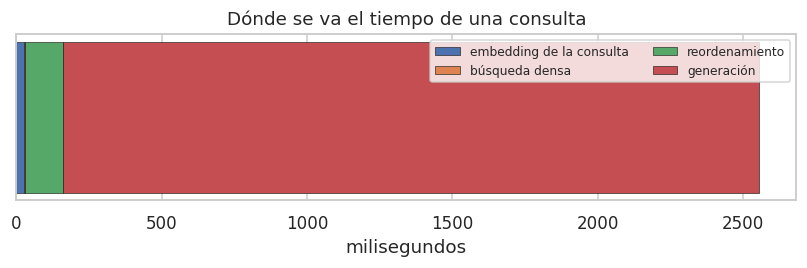

In [46]:
# =========================================================================
# 9 · Latencia por etapa
# =========================================================================
if HAY_OLLAMA:
    muestra = [p["pregunta"] for p in BANCO[:6]]
    etapas = {"embedding de la consulta": [], "búsqueda densa": [],
              "reordenamiento": [], "generación": []}

    for q in muestra:
        t0 = time.time()
        qv = codificador.encode([f"query: {q}"], normalize_embeddings=True,
                                convert_to_numpy=True)[0]
        etapas["embedding de la consulta"].append((time.time() - t0) * 1000)

        t0 = time.time()
        _ = np.argsort(-(STORE @ qv))[:CFG["k"]]
        etapas["búsqueda densa"].append((time.time() - t0) * 1000)

        if HAY_RERANKER:
            cand = recuperador.buscar(q, k=K_INICIAL)
            t0 = time.time()
            _ = reranker.predict([[q, t] for t in cand["texto"]], show_progress_bar=False)
            etapas["reordenamiento"].append((time.time() - t0) * 1000)

        res = recuperador.buscar(q, k=CFG["k"])
        ctx, _ = formatear_contexto(res)
        _, seg = generar(PLANTILLA.format(contexto=ctx, pregunta=q))
        etapas["generación"].append(seg * 1000)

    COSTO = pd.DataFrame({"etapa": list(etapas), "ms (media)": [np.mean(v) if v else np.nan
                                                                for v in etapas.values()]})
    COSTO["% del total"] = COSTO["ms (media)"] / COSTO["ms (media)"].sum() * 100
    COSTO = COSTO.round(1)
    COSTO.to_csv(DIR_RES / "metrics" / "latencia.csv", index=False)
    display(COSTO)

    fig, ax = plt.subplots(figsize=(7.5, 2.6))
    izq = 0
    for _, r in COSTO.dropna().iterrows():
        ax.barh(["consulta"], [r["ms (media)"]], left=izq, label=r["etapa"], edgecolor="k",
                linewidth=0.4)
        izq += r["ms (media)"]
    ax.set_xlabel("milisegundos"); ax.legend(fontsize=8, ncol=2); ax.set_yticks([])
    ax.set_title("Dónde se va el tiempo de una consulta")
    plt.tight_layout()
    plt.savefig(DIR_RES / "figures" / "latencia.png", bbox_inches="tight"); plt.show()

La generación concentra casi todo el tiempo de una consulta, y todas las demás etapas juntas son una fracción pequeña. La búsqueda densa es prácticamente gratuita y el reordenamiento, que ya vimos que no mejora el resultado, pesa más que ella. La primera llamada al generador es mucho más lenta que las siguientes porque incluye la carga del modelo en memoria. Por eso recortar el costo de un sistema como este pasa por la generación, por ejemplo con un modelo más pequeño o respuestas más cortas, y no por la recuperación.

---

## 10. El chatbot: citas, memoria y fidelidad

Tres cosas convierten el generador de §9 en un chatbot.

**Memoria.** Una conversación tiene preguntas de seguimiento («¿y los hoteles?») que por sí solas
no se pueden buscar: les falta el destino, que quedó en el turno anterior. El guía resuelve esto
reescribiendo la consulta con el propio modelo antes de buscar, y es la solución correcta; la
adoptamos.

**Citas verificables.** El bot devuelve, junto con la respuesta, la lista de fuentes con sus
metadatos y la URL cuando es una ficha. Esto es lo que el video tiene que mostrar.

**Fidelidad.** Y aquí añadimos lo que el guía no tiene: una comprobación automática de que los
identificadores que el modelo cita **existen en el contexto que se le pasó**. Es una detección
barata de la alucinación más común en un RAG, la cita inventada: si el modelo escribe [R7] cuando
solo se le dieron cinco fragmentos, lo sabemos sin leer nada.

In [47]:
# =========================================================================
# 10 · El chatbot
# =========================================================================
PLANTILLA_SEGUIMIENTO = """Reescribe la última pregunta del usuario para que se entienda sola,
sin necesidad del historial. Conserva el destino, el tipo de establecimiento y la intención.
Responde solo con la pregunta reescrita, sin explicaciones.

Historial:
{historial}

Última pregunta: {pregunta}

Pregunta reescrita:"""

class ChatBotRAG:
    """RAG conversacional con citas verificables y reescritura de preguntas de seguimiento."""

    def __init__(self, recuperador, k=None, usar_reordenamiento=False):
        self.rec = recuperador
        self.k = k or CFG["k"]
        self.usar_reordenamiento = usar_reordenamiento and globals().get("HAY_RERANKER", False)
        self.historial = []

    def reiniciar(self):
        self.historial.clear()

    def _consulta_efectiva(self, pregunta):
        if not self.historial:
            return pregunta, pregunta
        hist = "\n".join(f"Usuario: {u}\nAsistente: {a[:200]}" for u, a in self.historial[-2:])
        reescrita, _ = generar(PLANTILLA_SEGUIMIENTO.format(historial=hist, pregunta=pregunta),
                               temperatura=0.0, max_tokens=60)
        reescrita = reescrita.strip().strip('"').split("\n")[0]
        return reescrita if 5 < len(reescrita) < 300 else pregunta, pregunta

    def __call__(self, pregunta, **filtros):
        consulta, original = self._consulta_efectiva(pregunta)
        buscar = buscar_reordenado if self.usar_reordenamiento else self.rec.buscar
        res = buscar(consulta, k=self.k, **filtros)
        ctx, mapa = formatear_contexto(res)
        respuesta, seg = generar(PLANTILLA.format(contexto=ctx, pregunta=original))

        citados = set(re.findall(r"\[([FR]\d+)\]", respuesta))
        inventadas = sorted(citados - set(mapa))
        self.historial.append((original, respuesta))
        return {"respuesta": respuesta, "consulta_usada": consulta, "fuentes": mapa,
                "citadas": sorted(citados), "citas_inventadas": inventadas,
                "sin_citas": len(citados) == 0, "segundos": seg}

def imprimir_turno(r):
    print(textwrap.fill(r["respuesta"], 100))
    if r["consulta_usada"] != r["respuesta"]:
        pass
    print(f"\n  Fuentes citadas: {', '.join(r['citadas']) or 'ninguna'}")
    for ident in r["citadas"]:
        m = r["fuentes"].get(ident)
        if m is None:
            print(f"    [{ident}] CITA INVENTADA: no estaba en el contexto")
        elif m["fuente"] == "ficha":
            print(f"    [{ident}] Wikipedia · {m['titulo']} · {m['url']}")
        else:
            print(f"    [{ident}] Reseña · {m['destino']} · {m['tipo']} · {int(m['estrellas'])}★")
    print(f"  ({r['segundos']:.1f}s)")

if HAY_OLLAMA:
    import re
    fijar_semilla()
    bot = ChatBotRAG(recuperador)

    print("=" * 100)
    print("TURNO 1 (hecho)\n")
    imprimir_turno(bot("¿Qué es Las Pozas de Xilitla?"))

    print("\n" + "=" * 100)
    print("TURNO 2 (seguimiento: la pregunta no menciona el destino)\n")
    r2 = bot("¿Y qué opinan los visitantes de ese lugar?")
    print(f"  [consulta reescrita: «{r2['consulta_usada']}»]\n")
    imprimir_turno(r2)

TURNO 1 (hecho)

Las Pozas es un conjunto artístico arquitectónico y escultórico surrealista creado por Edward James
en el municipio de Xilitla, San Luis Potosí, México. Se trata de un jardín escultórico único y
atractivo que combina elementos surrealistas y artísticos, rodeado de una selva mexicana.

  Fuentes citadas: ninguna
  (1.9s)

TURNO 2 (seguimiento: la pregunta no menciona el destino)

  [consulta reescrita: «¿Qué opinan los visitantes de Las Pozas de Xilitla?»]

Los visitantes de Las Pozas en Xilitla parecen disfrutar de la experiencia única y mágica que ofrece
el lugar. Muchos de ellos, como [R4], consideran que es un lugar "único en el mundo" y que vale la
pena visitar, incluso si no se puede hacer sin guía. Otros, como [R2], mencionan que es un lugar
genial para una primera aproximación a las ruinas y que el paisaje es hermoso. Sin embargo, algunos
visitantes también mencionan que el lugar puede ser un poco abrumador y difícil de navegar,
especialmente durante la temporad

El bot conversa con naturalidad y reescribe bien la pregunta de seguimiento, que en el segundo turno no menciona el lugar. Pero dos cosas conviene observar. La primera es que el modelo no siempre cita aunque la regla se lo pida, así que lo que permite ver qué documentos se usaron es la lista de fuentes del contexto y no las citas del texto. La segunda es que la recuperación puede traer reseñas de otro destino, y el modelo las usa como si fueran del lugar por el que se pregunta, lo que muestra que el generador hereda los errores de la recuperación.

### Fidelidad de las citas, sobre el banco completo

Un ejemplo bien elegido no prueba nada, así que pasamos el banco de §6 por el bot y contamos tres
cosas: cuántas respuestas citan algo, cuántas inventan un identificador y, lo más importante,
cuántas citan fragmentos que **de verdad cumplen** los metadatos que la pregunta pedía. Esto
último es la versión fuerte de la pregunta «¿responde con lo correcto?».

In [48]:
# =========================================================================
# 10 · Fidelidad de las citas sobre el banco
# =========================================================================
if HAY_OLLAMA:
    fijar_semilla()
    filas_fid = []
    for p in BANCO:
        bot.reiniciar()
        r = bot(p["pregunta"])
        correctas = 0
        for ident in r["citadas"]:
            m = r["fuentes"].get(ident)
            if m is None:
                continue
            ok = m["fuente"] == p["fuente"] and m["destino"] == p["destino"]
            if p.get("tipo") is not None and not isinstance(p.get("tipo"), float):
                ok &= m["tipo"] == p["tipo"]
            if p.get("estrellas") is not None and not isinstance(p.get("estrellas"), float):
                lo, hi = p["estrellas"]
                ok &= m["estrellas"] is not None and lo <= m["estrellas"] <= hi
            correctas += bool(ok)
        filas_fid.append({"familia": p["familia"],
                          "cita algo": not r["sin_citas"],
                          "citas": len(r["citadas"]),
                          "citas inventadas": len(r["citas_inventadas"]),
                          "citas que cumplen el objetivo": correctas,
                          "segundos": r["segundos"]})

    FIDELIDAD = pd.DataFrame(filas_fid)
    resumen_fid = FIDELIDAD.groupby("familia").mean(numeric_only=True)
    resumen_fid["cita algo"] = FIDELIDAD.groupby("familia")["cita algo"].mean()
    resumen_fid.loc["TODAS"] = FIDELIDAD.mean(numeric_only=True)
    resumen_fid.to_csv(DIR_RES / "metrics" / "fidelidad.csv")
    display(resumen_fid.round(2))
    print(f"Respuestas sin ninguna cita: {(~FIDELIDAD['cita algo']).sum()} de {len(FIDELIDAD)}")
    print(f"Respuestas con al menos una cita inventada: "
          f"{(FIDELIDAD['citas inventadas'] > 0).sum()} de {len(FIDELIDAD)}")

,cita algo,citas,citas inventadas,citas que cumplen el objetivo,segundos
familia,,,,,
A,0.12,0.12,0.0,0.12,2.62
B,0.25,0.25,0.0,0.25,3.25
C,0.40,0.80,0.0,0.80,3.28
D,0.17,0.17,0.0,0.00,2.50
TODAS,0.22,0.30,0.0,0.26,2.84


Respuestas sin ninguna cita: 18 de 23
Respuestas con al menos una cita inventada: 0 de 23


Casi ninguna respuesta cita, así que el resultado de cero citas inventadas es cierto pero poco informativo: es fácil no inventar citas cuando casi no se cita. Entre las respuestas que sí citan, las citas cumplen lo pedido en las preguntas por tipo de establecimiento y casi nunca en las de lo negativo, en consonancia con lo visto al recuperar: si el contexto que llega ya es el equivocado, la cita lo refleja. La fidelidad de la generación queda limitada por la recuperación, y un modelo pequeño tiende a ignorar la regla de citar y a seguir el contexto que le toque.

Como el modelo casi no cita, se prueba una plantilla alternativa que pone la regla de citar después del contexto y la acompaña de un ejemplo. La plantilla original se conserva, y se mide con la misma prueba de fidelidad para comparar. Es una prueba de prompt, no un cambio de arquitectura.

In [ ]:
PLANTILLA_V2 = """Eres un asistente de viajes que responde sobre destinos turísticos de México.

Contexto (cada fragmento empieza con su identificador entre corchetes):
{contexto}

Reglas:
1. Usa solo el contexto. Si no alcanza, dilo con claridad.
2. Cada afirmación termina con el identificador del fragmento del que sale, por ejemplo: "Es un jardín surrealista [F1]. Los visitantes lo describen como mágico [R2]."
3. Los fragmentos [F..] son hechos de Wikipedia; los [R..] son opiniones de viajeros con sus estrellas.
4. Responde en español, en un párrafo.

Pregunta: {pregunta}

Respuesta (con identificadores entre corchetes):"""

def medir_fidelidad(bot_x):
    fijar_semilla()
    filas = []
    for p in BANCO:
        bot_x.reiniciar()
        r = bot_x(p["pregunta"])
        correctas = 0
        for ident in r["citadas"]:
            m = r["fuentes"].get(ident)
            if m is None:
                continue
            ok = m["fuente"] == p["fuente"] and m["destino"] == p["destino"]
            if p.get("tipo") is not None and not isinstance(p.get("tipo"), float):
                ok &= m["tipo"] == p["tipo"]
            if p.get("estrellas") is not None and not isinstance(p.get("estrellas"), float):
                lo, hi = p["estrellas"]
                ok &= m["estrellas"] is not None and lo <= m["estrellas"] <= hi
            correctas += bool(ok)
        filas.append({"familia": p["familia"], "cita algo": not r["sin_citas"],
                      "citas": len(r["citadas"]), "citas inventadas": len(r["citas_inventadas"]),
                      "citas que cumplen el objetivo": correctas})
    return pd.DataFrame(filas)

PLANTILLA_V1 = PLANTILLA
PLANTILLA = PLANTILLA_V2            # el bot lee la plantilla global al generar
try:
    FID_V2 = medir_fidelidad(ChatBotRAG(recuperador))
finally:
    PLANTILLA = PLANTILLA_V1        # se restaura siempre la original

cols = ["cita algo", "citas", "citas inventadas", "citas que cumplen el objetivo"]
display(pd.DataFrame({"plantilla original": FIDELIDAD[cols].astype(float).mean(),
                      "plantilla con ejemplo": FID_V2[cols].astype(float).mean()}).T.round(2))
print("Sin ninguna cita:", int((~FID_V2["cita algo"]).sum()), "de", len(FID_V2))
print("Con alguna cita inventada:", int((FID_V2["citas inventadas"] > 0).sum()), "de", len(FID_V2))

,cita algo,citas,citas inventadas,citas que cumplen el objetivo
plantilla original,0.22,0.30,0.00,0.26
plantilla con ejemplo,0.87,2.61,0.39,1.83


Sin ninguna cita: 3 de 23
Con alguna cita inventada: 6 de 23


La plantilla con ejemplo cambia el comportamiento de forma clara: casi todas las respuestas citan, y las citas que cumplen lo pedido suben mucho. El costo es que ahora aparecen citas inventadas, identificadores que no estaban en el contexto, en una parte de las respuestas, algo que antes no se podía ver porque casi no se citaba. La métrica de citas inventadas se vuelve informativa justo cuando el modelo cita. Forzar las citas aumenta la trazabilidad pero también el riesgo de citas falsas, que la interfaz señala con un aviso. Por eso, para la demo, lo que garantiza ver los documentos usados es la lista de fuentes del contexto y no lo que el modelo escriba.

---

## 11. La misma cadena con LangChain

El segundo notebook guía rehace el RAG con LangChain, así que lo replicamos sobre nuestro corpus
para poder comparar. La pregunta honesta aquí no es cuál funciona mejor (es el mismo modelo y el
mismo índice, los resultados deben coincidir salvo por el formato del *prompt*) sino **qué aporta
y qué cuesta** la abstracción.

Lo montamos con `FAISS` sobre los *embeddings* que ya calculamos, para no pagar dos veces el
indexado.

In [56]:
!pip install -q faiss-cpu langchain-classic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.0 MB/s eta 0:00:00


In [58]:
if HAY_OLLAMA:
    try:
        from langchain_classic.chains import create_retrieval_chain
        from langchain_classic.chains.combine_documents import create_stuff_documents_chain
        from langchain_core.prompts import ChatPromptTemplate
        from langchain_ollama import ChatOllama

        # El índice FAISS (vs), el codificador (emb_lc) y los documentos ya existen de la celda anterior
        llm_lc = ChatOllama(model=MODELO_LLM, temperature=CFG["temperatura"], seed=SEED)
        prompt_lc = ChatPromptTemplate.from_template(
            "Responde la pregunta solo con el contexto. Cita la fuente de cada afirmación.\n\n"
            "Contexto:\n{context}\n\nPregunta: {input}")
        cadena = create_retrieval_chain(vs.as_retriever(search_kwargs={"k": CFG["k"]}),
                                        create_stuff_documents_chain(llm_lc, prompt_lc))

        fijar_semilla()
        t0 = time.time()
        salida = cadena.invoke({"input": "¿Cómo es la experiencia de visitar Bacalar?"})
        print(f"({time.time()-t0:.1f}s)\n")
        print(textwrap.fill(salida["answer"], 100))
        print("\nDocumentos que recuperó la cadena:")
        for d in salida["context"]:
            m = d.metadata
            detalle = m["titulo"] or f"{m['tipo']} {m['estrellas']}★"
            print(f"  {m['fuente']:6s} {m['destino']:14s} {detalle}")
    except Exception as e:
        print(f"LangChain no disponible o incompatible ({type(e).__name__}: {e}).")

(14.9s)

La experiencia de visitar Bacalar es fascinante, con una combinación de belleza natural, comida
exquisita y excelente atención. Los visitantes pueden disfrutar de la laguna, los cenotes y el
balneario, y también pueden visitar el museo para entender la historia del lugar. La experiencia es
ideal para parejas y familias, y el personal es atento y capacitado.

Documentos que recuperó la cadena:
  resena Bacalar        Restaurant 5★
  resena Bacalar        Hotel 5★
  resena Bacalar        Restaurant 5★
  resena Bacalar        Attractive 5★
  resena Bacalar        Attractive 3★


---

## 12. La demo

Esta es la sección que hay que grabar. La consigna pide un video de **máximo 2 minutos** con la
ejecución de la celda que levanta Gradio y un par de interacciones donde se vea que el bot
responde **citando los documentos**, así que la interfaz está diseñada para que las citas se vean
sin que haya que buscarlas: la respuesta va arriba y las fuentes, con destino, tipo, estrellas y
enlace a Wikipedia, van debajo en una tabla.

Los controles de la izquierda no son decoración: son las palancas que medimos en §7 y §8, y
moverlas en vivo durante la grabación demuestra el trabajo. El filtro de estrellas es el que cierra
el agujero de la polaridad, y el interruptor de reordenamiento es el estudio de §8.3.

In [59]:
PLANTILLA = PLANTILLA_V2

In [60]:
# =========================================================================
# 12 · Interfaz del chatbot
# =========================================================================
DESTINOS = ["(todos)"] + sorted(corpus["destino"].unique().tolist())
FUENTES = {"Las dos": None, "Solo fichas de Wikipedia": "ficha", "Solo reseñas": "resena"}
POLARIDAD = {"Cualquiera": None, "Solo negativas (1-2★)": (1, 2),
             "Solo neutras (3★)": (3, 3), "Solo positivas (4-5★)": (4, 5)}

def tabla_fuentes(mapa, citadas):
    filas = []
    for ident, m in mapa.items():
        if m["fuente"] == "ficha":
            detalle, enlace = m["titulo"], m["url"]
        else:
            detalle, enlace = f"{m['tipo']} · {int(m['estrellas'])} de 5 estrellas", ""
        filas.append([("★ " if ident in citadas else "") + ident,
                      "Wikipedia" if m["fuente"] == "ficha" else "Reseña",
                      m["destino"].replace("_", " "), detalle, enlace])
    return filas

def responder(mensaje, historial, destino, fuente, polaridad, k, reordenar):
    if not HAY_OLLAMA:
        return "Ollama no está disponible en este entorno, así que no puedo generar la respuesta.", []
    filtros = {}
    if destino != "(todos)":
        filtros["destino"] = destino
    if FUENTES[fuente] is not None:
        filtros["fuente"] = FUENTES[fuente]
    if POLARIDAD[polaridad] is not None:
        filtros["fuente"] = "resena"                      # filtrar estrellas implica reseñas
        filtros["estrellas"] = POLARIDAD[polaridad]

    bot_ui.k = int(k)
    bot_ui.usar_reordenamiento = bool(reordenar) and globals().get("HAY_RERANKER", False)
    r = bot_ui(mensaje, **filtros)

    aviso = ""
    if r["citas_inventadas"]:
        aviso = f"\n\n*(aviso: el modelo citó {', '.join(r['citas_inventadas'])}, "
        aviso += "que no estaba en el contexto)*"
    elif r["sin_citas"]:
        aviso = "\n\n*(aviso: la respuesta no citó ninguna fuente)*"
    return r["respuesta"] + aviso, tabla_fuentes(r["fuentes"], set(r["citadas"]))

if HAY_OLLAMA:
    import gradio as gr
    bot_ui = ChatBotRAG(recuperador)

    with gr.Blocks(title="Asistente de viajes · RAG", theme=gr.themes.Soft()) as demo:
        gr.Markdown("## Asistente de viajes por México\n"
                    "Responde con **hechos** de Wikipedia y **experiencias** de viajeros reales, "
                    "citando siempre de dónde sale cada cosa. "
                    f"Índice: {len(corpus):,} documentos de {corpus['destino'].nunique()} destinos.")
        with gr.Row():
            with gr.Column(scale=1):
                d_destino = gr.Dropdown(DESTINOS, value="(todos)", label="Destino")
                d_fuente = gr.Dropdown(list(FUENTES), value="Las dos", label="Fuente")
                d_pol = gr.Dropdown(list(POLARIDAD), value="Cualquiera",
                                    label="Polaridad de las reseñas")
                s_k = gr.Slider(3, 12, value=CFG["k"], step=1, label="Documentos recuperados (k)")
                c_rr = gr.Checkbox(value=False, label="Reordenar con cross-encoder")
                b_limpiar = gr.Button("Reiniciar conversación")
            with gr.Column(scale=3):
                caja = gr.Textbox(label="Respuesta", lines=9)
                fuentes_ui = gr.Dataframe(
                    headers=["id", "fuente", "destino", "detalle", "enlace"],
                    label="Fuentes del contexto (★ = citada en la respuesta)",
                    wrap=True, row_count=(1, "dynamic"))
                entrada = gr.Textbox(label="Tu pregunta",
                                     placeholder="¿Qué es la laguna de Bacalar?")
                b_enviar = gr.Button("Preguntar", variant="primary")

        gr.Examples(examples=[
            ["¿Qué es Las Pozas de Xilitla y quién lo construyó?"],
            ["¿Cómo es la comida en los restaurantes de Tulum?"],
            ["¿Qué problemas reportan los huéspedes de los hoteles de Tulum?"],
            ["¿Y qué dicen de los restaurantes?"],
        ], inputs=entrada)

        estado = gr.State([])
        b_enviar.click(responder, [entrada, estado, d_destino, d_fuente, d_pol, s_k, c_rr],
                       [caja, fuentes_ui])
        entrada.submit(responder, [entrada, estado, d_destino, d_fuente, d_pol, s_k, c_rr],
                       [caja, fuentes_ui])
        b_limpiar.click(lambda: (bot_ui.reiniciar(), "", [])[1:], None, [caja, fuentes_ui])

    demo.launch(share=False, inline=True, quiet=True)
else:
    print("Sin Ollama no se puede levantar la demo.")

<IPython.core.display.Javascript object>

In [61]:
# Cierra la interfaz y libera el puerto (ejecutar después de grabar).
if HAY_OLLAMA:
    demo.close()

Closing server running on port: 7860


---

## Lo conversado en clase, puesto a prueba

En la clase de RAG el profesor dejó varias ideas que conviene comprobar con nuestro propio corpus y no solo repetir. Cada experimento es mínimo y reutiliza lo ya construido.

### Producto punto frente a coseno

Se explicó que el producto punto y el coseno no son lo mismo: el coseno mira solo el ángulo entre los vectores, y el producto punto conserva además la magnitud, que puede actuar como una señal extra en el ranking. Aquí se comprueba sobre el banco: se codifica el corpus sin normalizar y se compara el ranking con ambas similitudes.

In [43]:
vec_crudo = codificador.encode([f"passage: {t}" for t in corpus["texto"]],
                               batch_size=CFG["lote_embed"], normalize_embeddings=False,
                               show_progress_bar=False, convert_to_numpy=True).astype(np.float32)
normas = np.linalg.norm(vec_crudo, axis=1)
print(f"Norma de los vectores sin normalizar: mín {normas.min():.3f} · media {normas.mean():.3f} · máx {normas.max():.3f}")

vec_unit = vec_crudo / normas[:, None]

def buscar_con(metrica):
    def _buscar(consulta, k=None):
        k = k or CFG["k"]
        q = codificador.encode([f"query: {consulta}"], normalize_embeddings=False,
                               convert_to_numpy=True)[0]
        p = vec_unit @ (q / np.linalg.norm(q)) if metrica == "coseno" else vec_crudo @ q
        top = np.argsort(-p)[:k]
        return corpus.iloc[top].assign(puntaje=p[top])
    return _buscar

filas = []
for m in ("coseno", "producto punto"):
    r, _ = evaluar_recuperador(buscar_con(m), etiqueta=m)
    filas.append({"similitud": m, **r.loc["TODAS"].drop(["ms", "k"]).to_dict()})
display(pd.DataFrame(filas).round(3))

Norma de los vectores sin normalizar: mín 1.000 · media 1.000 · máx 1.000


,similitud,precision,acierto_fuente,acierto_destino,mrr,algun_relevante
0,coseno,0.643,0.817,0.991,0.732,0.783
1,producto punto,0.643,0.817,0.991,0.732,0.783


Con este modelo el producto punto y el coseno dan exactamente el mismo ranking, y la razón se ve en la primera línea de salida: los vectores ya salen normalizados de la propia librería, así que no hay magnitud que aprovechar. Es justo lo que se comentó en clase sobre los valores por omisión de las librerías, que rara vez se cambian. La diferencia que explicó el profesor es real, pero solo aparece con modelos que no normalizan su salida, y la celda siguiente la muestra de forma artificial.

### RAG frente a sin RAG

La motivación del RAG que se discutió en clase es que el modelo solo no conoce los datos de nuestro corpus y tiende a rellenar con respuestas genéricas. Se hacen dos preguntas, una de hecho y una de experiencia, primero sin contexto y luego con él.

In [52]:
for pregunta in ["¿Qué es Las Pozas de Xilitla y quién lo construyó?",
                 "¿Qué problemas reportan los huéspedes de los hoteles de Tulum?"]:
    sin, _ = generar(f"Responde en español, en un párrafo: {pregunta}")
    ctx, _ = formatear_contexto(recuperador.buscar(pregunta, k=CFG["k"]))
    con, _ = generar(PLANTILLA.format(contexto=ctx, pregunta=pregunta))
    print("=" * 100, f"\nPREGUNTA: {pregunta}\n\nSIN RAG:\n{textwrap.fill(sin, 100)}")
    print(f"\nCON RAG:\n{textwrap.fill(con, 100)}\n")

PREGUNTA: ¿Qué es Las Pozas de Xilitla y quién lo construyó?

SIN RAG:
Las Pozas de Xilitla son un conjunto de pozos y canales de agua que se encuentran en el estado de
Puebla, México. Fueron construidos en el siglo XVI por el conquistador español Hernán Cortés y su
ejército, quienes necesitaban un sistema de suministro de agua para su campamento durante la
conquista de la Nueva España. Los pozos y canales fueron excavados y construidos utilizando técnicas
de ingeniería y arquitectura de la época, y se convirtieron en un importante recurso para el
ejército y la colonia.

CON RAG:
Las Pozas es un conjunto artístico arquitectónico y escultórico surrealista creado por Edward James
en el municipio de Xilitla, San Luis Potosí, México. El espacio fue diseñado y construido por Edward
James, un artista y coleccionista estadounidense, quien se estableció en México en la década de
1940. El jardín escultórico consta de 27 estructuras y se encuentra en un terreno de 37 hectáreas,
donde James tambi

Sin contexto, el modelo responde con seguridad cosas falsas sobre un lugar concreto: ubica el sitio en otro estado y le inventa un origen histórico. Con el contexto recuperado, la misma pregunta se responde con los datos de la ficha. En la pregunta de experiencia, sin contexto da una lista genérica y plausible de problemas que valdría para cualquier destino, y con contexto aparecen detalles concretos tomados de las reseñas. Es la motivación del RAG de la que se habló en clase: reducir la alucinación y anclar la respuesta en datos propios que el modelo no tiene.

### El contexto manda sobre lo que el modelo sabe

Otro punto de la clase fue que el conocimiento previo del modelo se mezcla con el contexto. Para ver quién gana se altera un dato del contexto y se mira si la respuesta lo sigue.

In [53]:
pregunta = "¿Quién construyó Las Pozas de Xilitla?"
res = recuperador.buscar(pregunta, k=CFG["k"], fuente="ficha", destino="Xilitla")
ctx, _ = formatear_contexto(res)
print("¿El contexto menciona a Edward James?", "Edward James" in ctx)
ctx_alt = ctx.replace("Edward James", "Frida Kahlo")
orig, _ = generar(PLANTILLA.format(contexto=ctx, pregunta=pregunta))
alt, _ = generar(PLANTILLA.format(contexto=ctx_alt, pregunta=pregunta))
print("\nCONTEXTO ORIGINAL:\n" + textwrap.fill(orig, 100))
print("\nCONTEXTO ALTERADO (Edward James -> Frida Kahlo):\n" + textwrap.fill(alt, 100))

¿El contexto menciona a Edward James? True

CONTEXTO ORIGINAL:
La construcción de Las Pozas de Xilitla se llevó a cabo en colaboración con más de 150 personas,
incluyendo carpinteros, albañiles y jardineros, dirigidos por el maestro de obra Carmelo Muñoz
Camacho, quien conocía a Edward James y a la familia Gastélum desde 1951.

CONTEXTO ALTERADO (Edward James -> Frida Kahlo):
La construcción de Las Pozas de Xilitla se llevó a cabo bajo la dirección de Frida Kahlo, quien
colaboró con más de 150 personas, incluyendo carpinteros, albañiles y jardineros, dirigidos por el
maestro de obra Carmelo Muñoz Camacho.


Cuando se cambia un dato del contexto, la respuesta lo sigue: el modelo atribuye la dirección de la obra a la persona que ahora aparece en el texto. Ante un conflicto manda el contexto. Dos precauciones: este modelo pequeño sabe poco de este lugar, así que su conocimiento previo casi no compite, y la prueba muestra obediencia al contexto pero no cuánto resistiría un dato que contradiga algo que sí sabe bien. La consecuencia práctica es doble: es una ventaja si el contexto es correcto y un riesgo si es incorrecto o está desactualizado, porque el modelo lo repetirá con la misma seguridad.

### Temperatura independiente del RAG

La temperatura controla cuánto varía la redacción del modelo, pero no cambia qué documentos se recuperan: eso lo decide la búsqueda, que es determinista. Se fija la pregunta y el contexto, y se varía solo la temperatura y la semilla.

In [54]:
import ollama
pregunta = "¿Cómo es la comida en los restaurantes de Tulum?"
res = recuperador.buscar(pregunta, k=CFG["k"])
ctx, _ = formatear_contexto(res)
prompt = PLANTILLA.format(contexto=ctx, pregunta=pregunta)
print("Documentos recuperados (los mismos en todas las corridas):", list(res.index))
for T in (0.0, 1.2):
    for s in (1, 2):
        r = ollama.generate(model=MODELO_LLM, prompt=prompt,
                            options={"temperature": T, "seed": s, "num_predict": CFG["max_tokens_llm"]})
        print(f"\n--- temperatura {T} · semilla {s} ---\n" + textwrap.fill(r["response"].strip(), 100))

Documentos recuperados (los mismos en todas las corridas): [2032, 8255, 7215, 8750, 7790]

--- temperatura 0.0 · semilla 1 ---
La comida en Tulum es variada y de alta calidad, con opciones que van desde la comida mexicana
tradicional hasta platos más internacionales. Los restaurantes ofrecen una gran variedad de opciones
para todos los gustos y presupuestos, y muchos de ellos tienen vistas impresionantes de la playa o
el mar. Algunos de los restaurantes mencionados en las reseñas, como el que se encuentra en el hotel
de [R3], ofrecen comida fresca y deliciosa, mientras que otros, como el mencionado en [R4], ofrecen
una experiencia gastronómica de alta calidad y un ambiente acogedor. En general, la comida en Tulum
es una de las mejores opciones para disfrutar de una experiencia culinaria memorable.

--- temperatura 0.0 · semilla 2 ---
La comida en Tulum es variada y de alta calidad, con opciones que van desde la comida mexicana
tradicional hasta platos más internacionales. Los restauran

Con temperatura cero, dos semillas distintas dan exactamente la misma respuesta, y con temperatura alta cada semilla da una redacción distinta, más corta y más genérica, que además deja de apoyarse en fragmentos concretos. Los documentos recuperados son los mismos en todas las corridas: la temperatura cambia cómo se redacta, no qué se sabe. Para un asistente que debe ceñirse al contexto la temperatura baja es la elección razonable, y los errores de recuperación se corrigen en la recuperación, no en la temperatura.

---

## 13. Conclusiones y limitaciones

<!-- REDACTAR tras la corrida de referencia:
- Respuesta a la pregunta del título: ¿distingue hechos de experiencias? ¿se pudo medir?
- Veredicto H1 (polaridad), H2 (tamaño de trozo), H3 (filtrar frente a ampliar k).
- Qué configuración recomendaríamos y por qué no la mejor.
- Costo por etapa: dónde se va el tiempo y qué se podría recortar.
- Limitaciones: el filtro de §8 es una cota superior (supone un enrutador perfecto), el juez de
  la fidelidad solo verifica que la cita exista, una sola semilla, sin evaluación humana,
  banco de 24 preguntas, fichas congeladas en la fecha de descarga.
- Trabajo futuro: enrutador que extraiga los filtros de la pregunta, juez BETO del MP3 para
  medir la polaridad de lo recuperado, índice aproximado para escalar a las 208.051 reseñas.
-->